## Setup

In [ ]:
# Install huggingface_hub and download the data. Mirrors README "Setup -> Get the data".
!pip install -q huggingface_hub
!hf download db-d2/primevul-codebert-embeddings --repo-type dataset --local-dir ../data/hf_download
!mkdir -p ../data/processed/embeddings ../data/processed/embeddings_vulberta ../data/raw/PrimeVul_v0.1
!cp ../data/hf_download/*.npz ../data/processed/embeddings/
!cp ../data/hf_download/vulberta/*.npz ../data/processed/embeddings_vulberta/
!cp ../data/hf_download/raw/*.jsonl ../data/raw/PrimeVul_v0.1/
!rm -rf ../data/hf_download

In [ ]:
# Data prep: generate PU splits, set EMBEDDING_DIR, pick a torch device.
import os
import subprocess
import sys
from pathlib import Path

import torch

ROOT = Path("..").resolve()

(ROOT / "experiments" / "logs_reproduce").mkdir(parents=True, exist_ok=True)
(ROOT / "figures" / "reproduce").mkdir(parents=True, exist_ok=True)
(ROOT / "checkpoints" / "reproduce").mkdir(parents=True, exist_ok=True)

# Generate PU splits the notebook uses (README "Setup -> Generate PU splits").
prepare = ROOT / "data" / "prepare_pu_splits.py"
for frac in [0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.80]:
    for seed in [42, 123, 456, 789, 999]:
        sd = ROOT / "data" / "processed" / f"frac{frac:.2f}_seed{seed}"
        if not sd.exists():
            subprocess.check_call(
                [sys.executable, str(prepare), "--labeled-frac", str(frac), "--seed", str(seed)],
                cwd=str(ROOT), stdout=subprocess.DEVNULL,
            )

# src/evaluate.py reads test_paired.npz from EMBEDDING_DIR. Default to CodeBERT.
os.environ["EMBEDDING_DIR"] = str(ROOT / "data" / "processed" / "embeddings")

if torch.cuda.is_available():
    DEVICE_NAME = "cuda"
elif torch.backends.mps.is_available():
    DEVICE_NAME = "mps"
else:
    DEVICE_NAME = "cpu"
print(f"Torch device: {DEVICE_NAME}")

## 01 Data exploration

In [2]:
import json
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project root
ROOT = Path("..").resolve()
DATA_RAW = ROOT / "data" / "raw" / "PrimeVul_v0.1"
EMB_CB = ROOT / "data" / "processed" / "embeddings"
EMB_VB = ROOT / "data" / "processed" / "embeddings_vulberta"

sys.path.insert(0, str(ROOT / "src"))

# Dark theme for all plots
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#30363d",
    "grid.alpha": 0.5,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3",
    "font.size": 12,
    "figure.dpi": 150,
})

In [3]:
def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            records.append(json.loads(line.strip()))
    return records

splits = {}
for name, fname in [("train", "primevul_train.jsonl"), 
                     ("valid", "primevul_valid.jsonl"),
                     ("test", "primevul_test.jsonl"),
                     ("test_paired", "primevul_test_paired.jsonl")]:
    path = DATA_RAW / fname
    if path.exists():
        records = load_jsonl(path)
        n_vuln = sum(1 for r in records if r["target"] == 1)
        splits[name] = {"records": records, "total": len(records), "vuln": n_vuln}
        print(f"{name:15s}: {len(records):>8,} total, {n_vuln:>6,} vulnerable ({n_vuln/len(records):.2%})")

print(f"\nClass prior (train): {splits['train']['vuln'] / splits['train']['total']:.4f}")

train          :  175,797 total,  4,862 vulnerable (2.77%)
valid          :   23,948 total,    593 vulnerable (2.48%)
test           :   24,788 total,    549 vulnerable (2.21%)
test_paired    :      870 total,    435 vulnerable (50.00%)

Class prior (train): 0.0277


In [4]:
# Show a vulnerable sample (truncate func for readability)
sample = splits["train"]["records"][0]
display_sample = {k: (v[:200] + "..." if isinstance(v, str) and len(v) > 200 else v) 
                  for k, v in sample.items()}
print(json.dumps(display_sample, indent=2))

{
  "idx": 0,
  "project": "openssl",
  "commit_id": "ca989269a2876bae79393bd54c3e72d49975fc75",
  "project_url": "https://github.com/openssl/openssl",
  "commit_url": "https://git.openssl.org/gitweb/?p=openssl.git;a=commit;h=ca989269a2876bae79393bd54c3e72d49975fc75",
  "commit_message": "Use version in SSL_METHOD not SSL structure.\n\nWhen deciding whether to use TLS 1.2 PRF and record hash algorithms\nuse the version number in the corresponding SSL_METHOD structure\ninstead of the SSL st...",
  "target": 1,
  "func": " long ssl_get_algorithm2(SSL *s)\n        {\n        long alg2 = s->s3->tmp.new_cipher->algorithm2;\n       if (TLS1_get_version(s) >= TLS1_2_VERSION &&\n            alg2 == (SSL_HANDSHAKE_MAC_DEFAULT|TLS...",
  "func_hash": 255087747659226932756944884868284698117,
  "file_name": "None",
  "file_hash": null,
  "cwe": [
    "CWE-310"
  ],
  "cve": "CVE-2013-6449",
  "cve_desc": "The ssl_get_algorithm2 function in ssl/s3_lib.c in OpenSSL before 1.0.2 obtains a certain ver

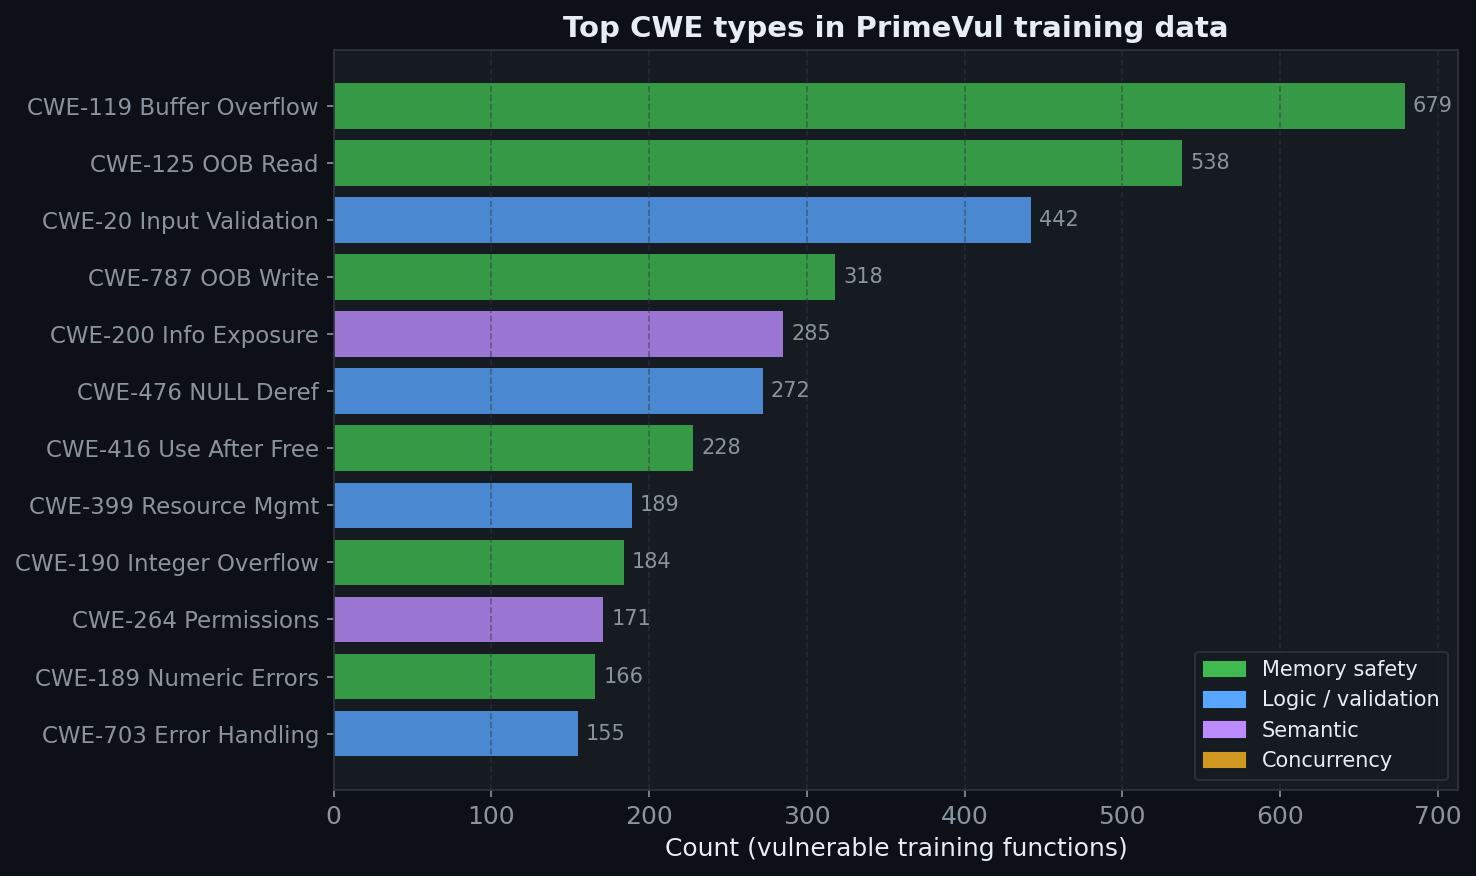


Total unique CWEs: 119


In [5]:
# Count CWEs in training vulnerable functions
cwe_counts = Counter()
for r in splits["train"]["records"]:
    if r["target"] == 1:
        for c in (r.get("cwe") or []):
            cwe_counts[c] += 1

top_cwes = cwe_counts.most_common(12)

# CWE category colors
CWE_CATEGORY = {
    "CWE-119": "mem", "CWE-125": "mem", "CWE-787": "mem", "CWE-416": "mem",
    "CWE-190": "mem", "CWE-415": "mem",
    "CWE-20": "logic", "CWE-476": "logic", "CWE-703": "logic", "CWE-617": "logic",
    "CWE-200": "semantic", "CWE-264": "semantic",
    "CWE-362": "concurrency", "CWE-399": "logic", "CWE-189": "mem",
    "CWE-401": "mem", "CWE-772": "mem",
}
CAT_COLORS = {"mem": "#3fb950", "logic": "#58a6ff", "semantic": "#bc8cff", "concurrency": "#d29922"}

CWE_NAMES = {
    "CWE-119": "Buffer Overflow", "CWE-125": "OOB Read", "CWE-20": "Input Validation",
    "CWE-787": "OOB Write", "CWE-200": "Info Exposure", "CWE-476": "NULL Deref",
    "CWE-416": "Use After Free", "CWE-399": "Resource Mgmt", "CWE-190": "Integer Overflow",
    "CWE-264": "Permissions", "CWE-189": "Numeric Errors", "CWE-703": "Error Handling",
    "CWE-362": "Race Condition", "CWE-401": "Memory Leak",
}

fig, ax = plt.subplots(figsize=(10, 6))
cwes = [c for c, _ in top_cwes]
counts = [n for _, n in top_cwes]
colors = [CAT_COLORS.get(CWE_CATEGORY.get(c, "logic"), "#8b949e") for c in cwes]
labels = [f"{c} {CWE_NAMES.get(c, '')}" for c in cwes]

bars = ax.barh(range(len(cwes)), counts, color=colors, alpha=0.8)
ax.set_yticks(range(len(cwes)))
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Count (vulnerable training functions)")
ax.set_title("Top CWE types in PrimeVul training data", fontsize=14, fontweight="bold")
ax.grid(axis="x", linestyle="--")

# Value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(count),
            va="center", fontsize=10, color="#8b949e")

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color="#3fb950", label="Memory safety"),
    Patch(color="#58a6ff", label="Logic / validation"),
    Patch(color="#bc8cff", label="Semantic"),
    Patch(color="#d29922", label="Concurrency"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb01_cwe_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nTotal unique CWEs: {len(cwe_counts)}")

In [6]:
for model_name, emb_dir in [("CodeBERT", EMB_CB), ("VulBERTa", EMB_VB)]:
    print(f"=== {model_name} ===")
    for split in ["train", "valid", "test", "test_paired"]:
        path = emb_dir / f"{split}.npz"
        if not path.exists():
            print(f"  {split}: MISSING")
            continue
        data = np.load(path, allow_pickle=False)
        embs = data["embeddings"]
        labels = data["labels"]
        l2 = np.linalg.norm(embs, axis=1).mean()
        n_nan = np.isnan(embs).sum()
        print(f"  {split:12s}: shape={embs.shape}, pos={int((labels==1).sum()):>5}, "
              f"L2={l2:.2f}, NaN={n_nan}")
    print()

# Verify labels and idxs match between models
for split in ["train", "test"]:
    cb = np.load(EMB_CB / f"{split}.npz", allow_pickle=False)
    vb = np.load(EMB_VB / f"{split}.npz", allow_pickle=False)
    labels_match = np.array_equal(cb["labels"], vb["labels"])
    idxs_match = np.array_equal(cb["idxs"], vb["idxs"])
    print(f"{split}: labels match={labels_match}, idxs match={idxs_match}")

=== CodeBERT ===
  train       : shape=(175797, 768), pos= 4862, L2=21.38, NaN=0
  valid       : shape=(23948, 768), pos=  593, L2=21.39, NaN=0
  test        : shape=(24788, 768), pos=  549, L2=21.40, NaN=0
  test_paired : shape=(870, 768), pos=  435, L2=21.61, NaN=0

=== VulBERTa ===
  train       : shape=(175797, 768), pos= 4862, L2=27.03, NaN=0
  valid       : shape=(23948, 768), pos=  593, L2=27.03, NaN=0
  test        : shape=(24788, 768), pos=  549, L2=27.03, NaN=0
  test_paired : shape=(870, 768), pos=  435, L2=27.01, NaN=0

train: labels match=True, idxs match=True
test: labels match=True, idxs match=True


In [7]:
split_dir = ROOT / "data" / "processed" / "frac0.20_seed42"
with open(split_dir / "metadata.json") as f:
    meta = json.load(f)

print("PU Split at 20% labeling (seed=42):")
print(f"  P (labeled positive): {meta['n_P']:,} functions")
print(f"  U (unlabeled):        {meta['n_U']:,} functions")
print(f"  Hidden vuln in U:     {meta['n_hidden_vuln_in_U']:,} ({meta['n_hidden_vuln_in_U']/meta['n_U']:.2%} of U)")
print(f"  Class prior:          {meta['class_prior']:.4f}")

# CWE composition of P across seeds
print("\nCWE composition of P across 3 split seeds:")
for seed in [42, 123, 456]:
    sd = ROOT / "data" / "processed" / f"frac0.20_seed{seed}"
    cwes = Counter()
    with open(sd / "P.jsonl") as f:
        for line in f:
            for c in (json.loads(line).get("cwe") or []):
                cwes[c] += 1
    top3 = cwes.most_common(3)
    print(f"  seed={seed}: {', '.join(f'{c}={n}' for c, n in top3)} ...")

PU Split at 20% labeling (seed=42):
  P (labeled positive): 972 functions
  U (unlabeled):        174,825 functions
  Hidden vuln in U:     3,890 (2.23% of U)
  Class prior:          0.0277

CWE composition of P across 3 split seeds:
  seed=42: CWE-119=148, CWE-125=109, CWE-20=81 ...
  seed=123: CWE-119=143, CWE-125=118, CWE-20=86 ...
  seed=456: CWE-119=144, CWE-20=107, CWE-125=105 ...


Fitting UMAP for CodeBERT...


/Users/dbenson/.pyenv/versions/stat4243/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP for VulBERTa...


/Users/dbenson/.pyenv/versions/stat4243/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


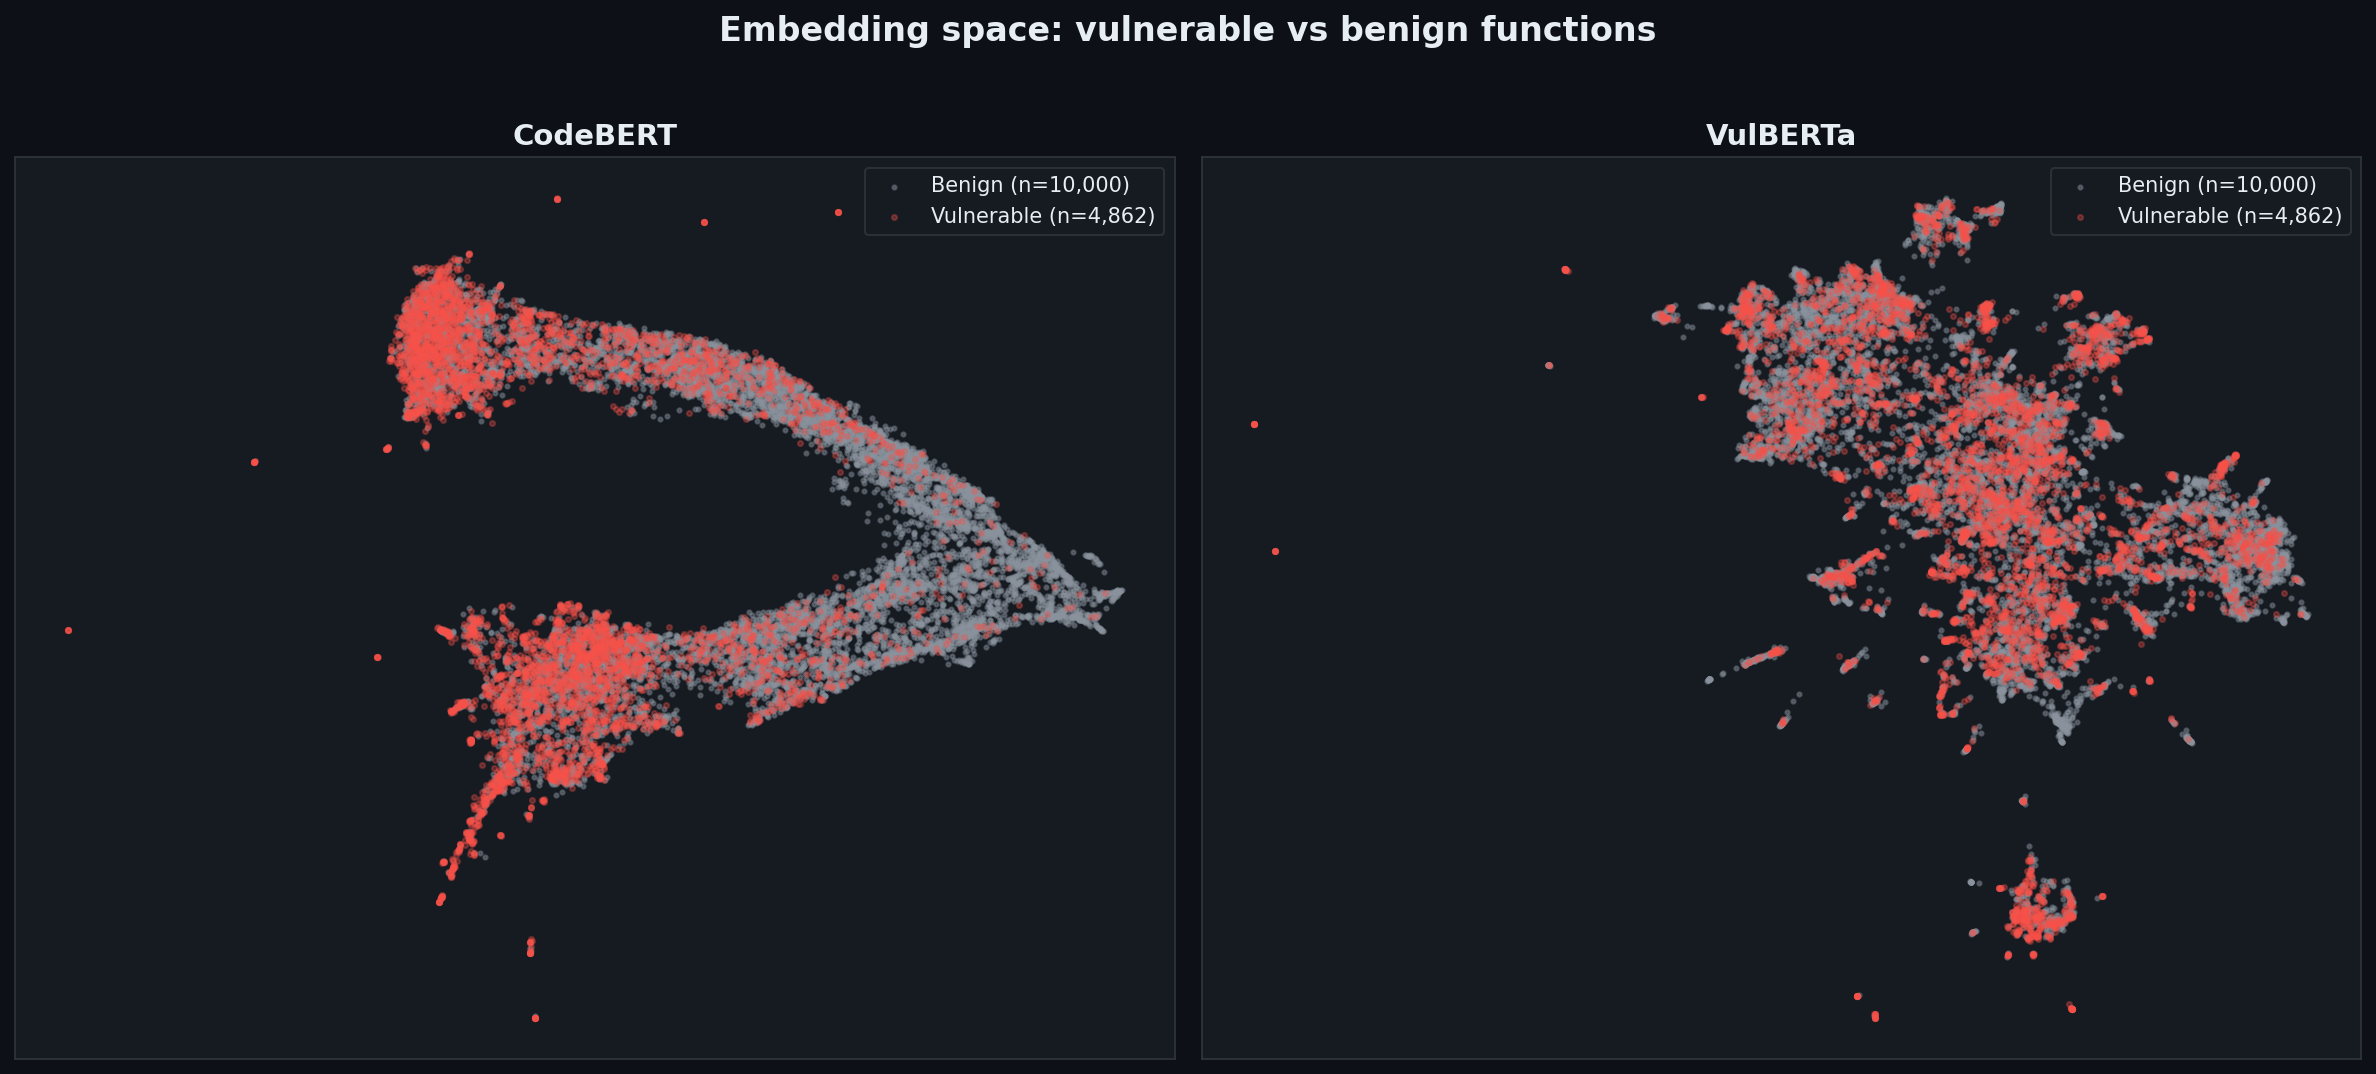


Both models show heavy overlap between vulnerable and benign functions.
The frozen [CLS] embeddings do not cleanly separate the two classes.


In [8]:
import umap
import warnings
warnings.filterwarnings("ignore", message=".*spectral.*")

def compute_umap(emb_dir, seed=42):
    data = np.load(emb_dir / "train.npz", allow_pickle=False)
    X, y = data["embeddings"], data["labels"]
    
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    rng = np.random.RandomState(seed)
    neg_sample = rng.choice(neg_idx, size=10000, replace=False)
    idx = np.concatenate([neg_sample, pos_idx])
    rng.shuffle(idx)
    
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=seed)
    embedding = reducer.fit_transform(X[idx])
    return embedding, y[idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (name, emb_dir) in zip(axes, [("CodeBERT", EMB_CB), ("VulBERTa", EMB_VB)]):
    print(f"Fitting UMAP for {name}...")
    emb_2d, labels = compute_umap(emb_dir)
    
    neg_mask = labels == 0
    pos_mask = labels == 1
    
    ax.scatter(emb_2d[neg_mask, 0], emb_2d[neg_mask, 1],
               c="#8b949e", s=4, alpha=0.4, label=f"Benign (n={neg_mask.sum():,})", rasterized=True)
    ax.scatter(emb_2d[pos_mask, 0], emb_2d[pos_mask, 1],
               c="#f85149", s=6, alpha=0.3, label=f"Vulnerable (n={pos_mask.sum():,})", rasterized=True)
    
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", fontsize=10, framealpha=0.8)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Embedding space: vulnerable vs benign functions", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb01_umap_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nBoth models show heavy overlap between vulnerable and benign functions.")
print("The frozen [CLS] embeddings do not cleanly separate the two classes.")

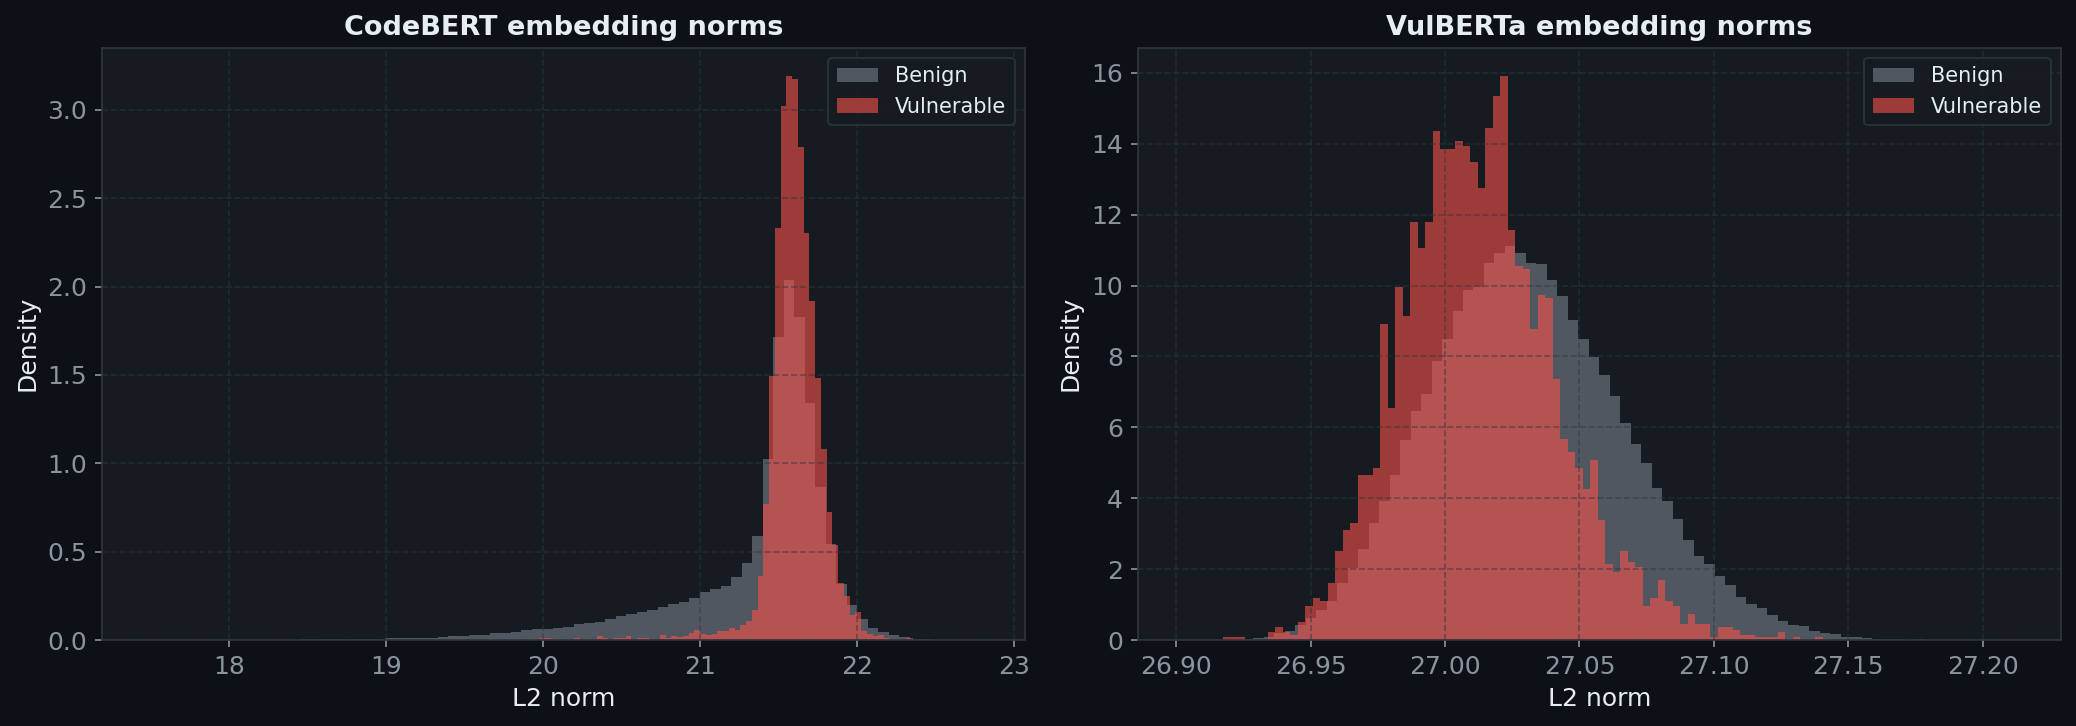

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, emb_dir, color) in zip(axes, [
    ("CodeBERT", EMB_CB, "#58a6ff"), ("VulBERTa", EMB_VB, "#bc8cff")
]):
    data = np.load(emb_dir / "train.npz", allow_pickle=False)
    X, y = data["embeddings"], data["labels"]
    norms = np.linalg.norm(X, axis=1)
    
    ax.hist(norms[y == 0], bins=80, alpha=0.5, color="#8b949e", label="Benign", density=True)
    ax.hist(norms[y == 1], bins=80, alpha=0.6, color="#f85149", label="Vulnerable", density=True)
    ax.set_xlabel("L2 norm")
    ax.set_ylabel("Density")
    ax.set_title(f"{name} embedding norms", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--")

plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb01_embedding_norms.png", dpi=300, bbox_inches="tight")
plt.show()

## 02 Baseline comparison

In [10]:
import sys, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from training import (
    train_supervised, train_naive_pu, train_nnpu, train_self_training,
    find_best_threshold, load_split_embeddings, set_seed,
)
from model import VulnMLP
from evaluate import compute_vds, compute_pairwise_accuracy

# Dark theme
plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3", "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "grid.color": "#30363d", "grid.alpha": 0.5,
    "legend.facecolor": "#161b22", "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3", "font.size": 12, "figure.dpi": 150,
})

COLORS = {
    "supervised": "#3fb950", "naive_pu": "#d29922",
    "nnpu": "#58a6ff", "self_training": "#bc8cff",
}
SEEDS = [42, 123, 456]
FRAC = 0.20
PRIOR = 0.0277
CKPT_DIR = ROOT / "checkpoints" / "reproduce"
CKPT_DIR.mkdir(exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

Device: mps


In [11]:
EMB_DIR = str(ROOT / "data" / "processed" / "embeddings")

# Store results: {method: {seed: {"model": model, "history": history}}}
cb_results = {}

for seed in SEEDS:
    print(f"\n--- Seed {seed} ---")
    
    # Supervised
    model, hist = train_supervised(embedding_dir=EMB_DIR, seed=seed, device=device)
    torch.save(model.state_dict(), CKPT_DIR / f"nb02_supervised_cb_{seed}.pt")
    cb_results.setdefault("supervised", {})[seed] = {"model": model, "history": hist}
    print(f"  Supervised: {len(hist['train_loss'])} epochs, best={hist['best_epoch']}, "
          f"AUROC={hist['val_auroc'][hist['best_epoch']-1]:.4f}")
    
    # Naive PU
    model, hist = train_naive_pu(embedding_dir=EMB_DIR, labeled_frac=FRAC, 
                                  split_seed=seed, model_seed=seed, device=device)
    torch.save(model.state_dict(), CKPT_DIR / f"nb02_naive_pu_cb_{seed}.pt")
    cb_results.setdefault("naive_pu", {})[seed] = {"model": model, "history": hist}
    print(f"  Naive PU:   {len(hist['train_loss'])} epochs, best={hist['best_epoch']}, "
          f"AUROC={hist['val_auroc'][hist['best_epoch']-1]:.4f}")
    
    # nnPU
    model, hist = train_nnpu(embedding_dir=EMB_DIR, labeled_frac=FRAC,
                              split_seed=seed, model_seed=seed, prior=PRIOR, device=device)
    torch.save(model.state_dict(), CKPT_DIR / f"nb02_nnpu_cb_{seed}.pt")
    cb_results.setdefault("nnpu", {})[seed] = {"model": model, "history": hist}
    print(f"  nnPU:       {len(hist['train_loss'])} epochs, best={hist['best_epoch']}, "
          f"AUROC={hist['val_auroc'][hist['best_epoch']-1]:.4f}")
    
    # Self-training
    model, hist = train_self_training(embedding_dir=EMB_DIR, labeled_frac=FRAC,
                                       split_seed=seed, model_seed=seed, device=device)
    torch.save(model.state_dict(), CKPT_DIR / f"nb02_self_training_cb_{seed}.pt")
    cb_results.setdefault("self_training", {})[seed] = {"model": model, "history": hist}
    print(f"  Self-train: best_iter={hist['best_iteration']}, "
          f"AUROC={hist['iter_val_auroc'][hist['best_iteration']]:.4f}")

print("\nCodeBERT training complete.")


--- Seed 42 ---
  Supervised: 30 epochs, best=30, AUROC=0.8085
  Naive PU:   30 epochs, best=27, AUROC=0.8014
  nnPU:       9 epochs, best=4, AUROC=0.8029
  Self-train: best_iter=0, AUROC=0.7952

--- Seed 123 ---
  Supervised: 22 epochs, best=17, AUROC=0.8057
  Naive PU:   30 epochs, best=28, AUROC=0.7964
  nnPU:       8 epochs, best=3, AUROC=0.7974
  Self-train: best_iter=0, AUROC=0.7912

--- Seed 456 ---
  Supervised: 19 epochs, best=14, AUROC=0.8049
  Naive PU:   30 epochs, best=30, AUROC=0.7985
  nnPU:       8 epochs, best=3, AUROC=0.7980
  Self-train: best_iter=0, AUROC=0.7904

CodeBERT training complete.


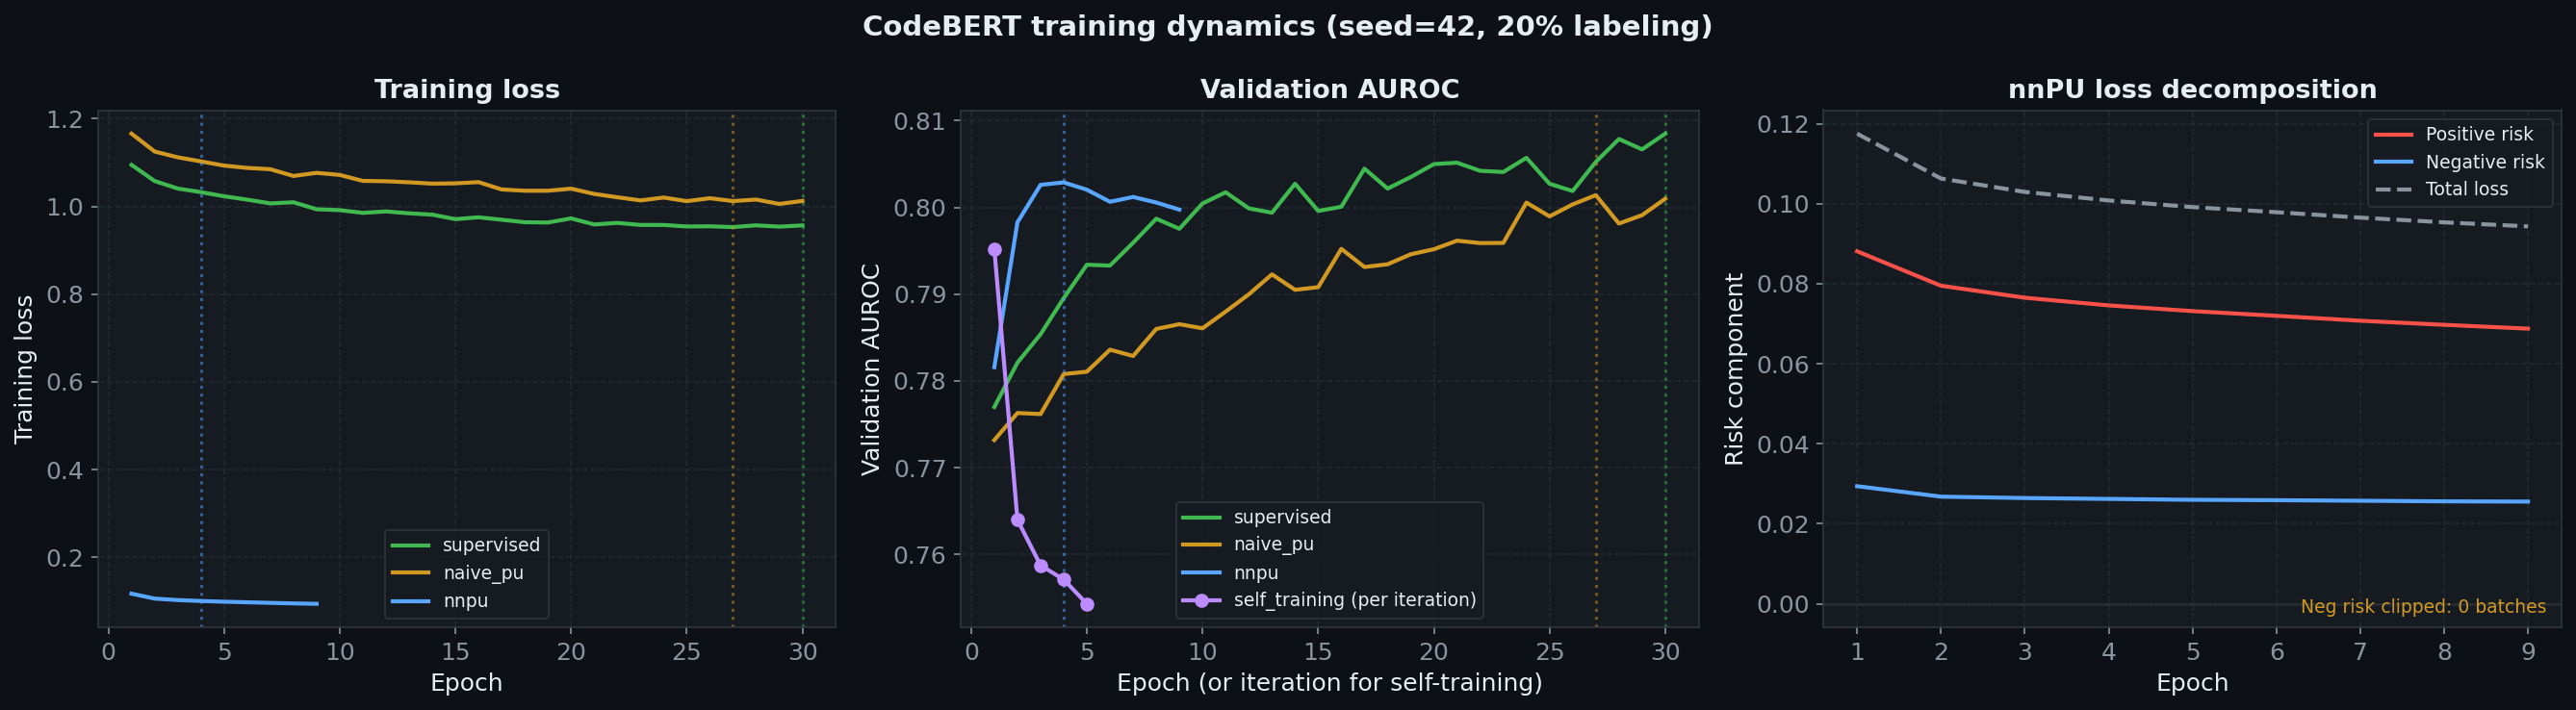

In [12]:
seed = 42  # Show curves for one seed

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Training loss
ax = axes[0]
for method in ["supervised", "naive_pu", "nnpu", "self_training"]:
    h = cb_results[method][seed]["history"]
    if "train_loss" in h:
        ax.plot(range(1, len(h["train_loss"])+1), h["train_loss"],
                color=COLORS[method], label=method, linewidth=2)
        # Mark best epoch
        ax.axvline(x=h["best_epoch"], color=COLORS[method], linestyle=":", alpha=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Training loss", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--")

# Panel 2: Validation AUROC
ax = axes[1]
for method in ["supervised", "naive_pu", "nnpu"]:
    h = cb_results[method][seed]["history"]
    ax.plot(range(1, len(h["val_auroc"])+1), h["val_auroc"],
            color=COLORS[method], label=method, linewidth=2)
    ax.axvline(x=h["best_epoch"], color=COLORS[method], linestyle=":", alpha=0.5)
# Self-training has per-iteration AUROC, not per-epoch
h_st = cb_results["self_training"][seed]["history"]
ax.plot(range(1, len(h_st["iter_val_auroc"])+1), h_st["iter_val_auroc"],
        color=COLORS["self_training"], label="self_training (per iteration)",
        linewidth=2, marker="o", markersize=6)
ax.set_xlabel("Epoch (or iteration for self-training)")
ax.set_ylabel("Validation AUROC")
ax.set_title("Validation AUROC", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--")

# Panel 3: nnPU loss decomposition
ax = axes[2]
h = cb_results["nnpu"][seed]["history"]
epochs = range(1, len(h["positive_risk"])+1)
ax.plot(epochs, h["positive_risk"], color="#f85149", label="Positive risk", linewidth=2)
ax.plot(epochs, h["negative_risk"], color="#58a6ff", label="Negative risk", linewidth=2)
ax.plot(epochs, h["train_loss"], color="#8b949e", label="Total loss", linewidth=2, linestyle="--")
ax.axhline(y=0, color="#30363d", linestyle="-", alpha=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Risk component")
ax.set_title("nnPU loss decomposition", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--")

# Add clip count as text
total_clips = sum(h["neg_clipped_count"])
ax.text(0.98, 0.02, f"Neg risk clipped: {total_clips} batches",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="#d29922")

fig.suptitle("CodeBERT training dynamics (seed=42, 20% labeling)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb02_training_curves_cb.png", dpi=300, bbox_inches="tight")
plt.show()

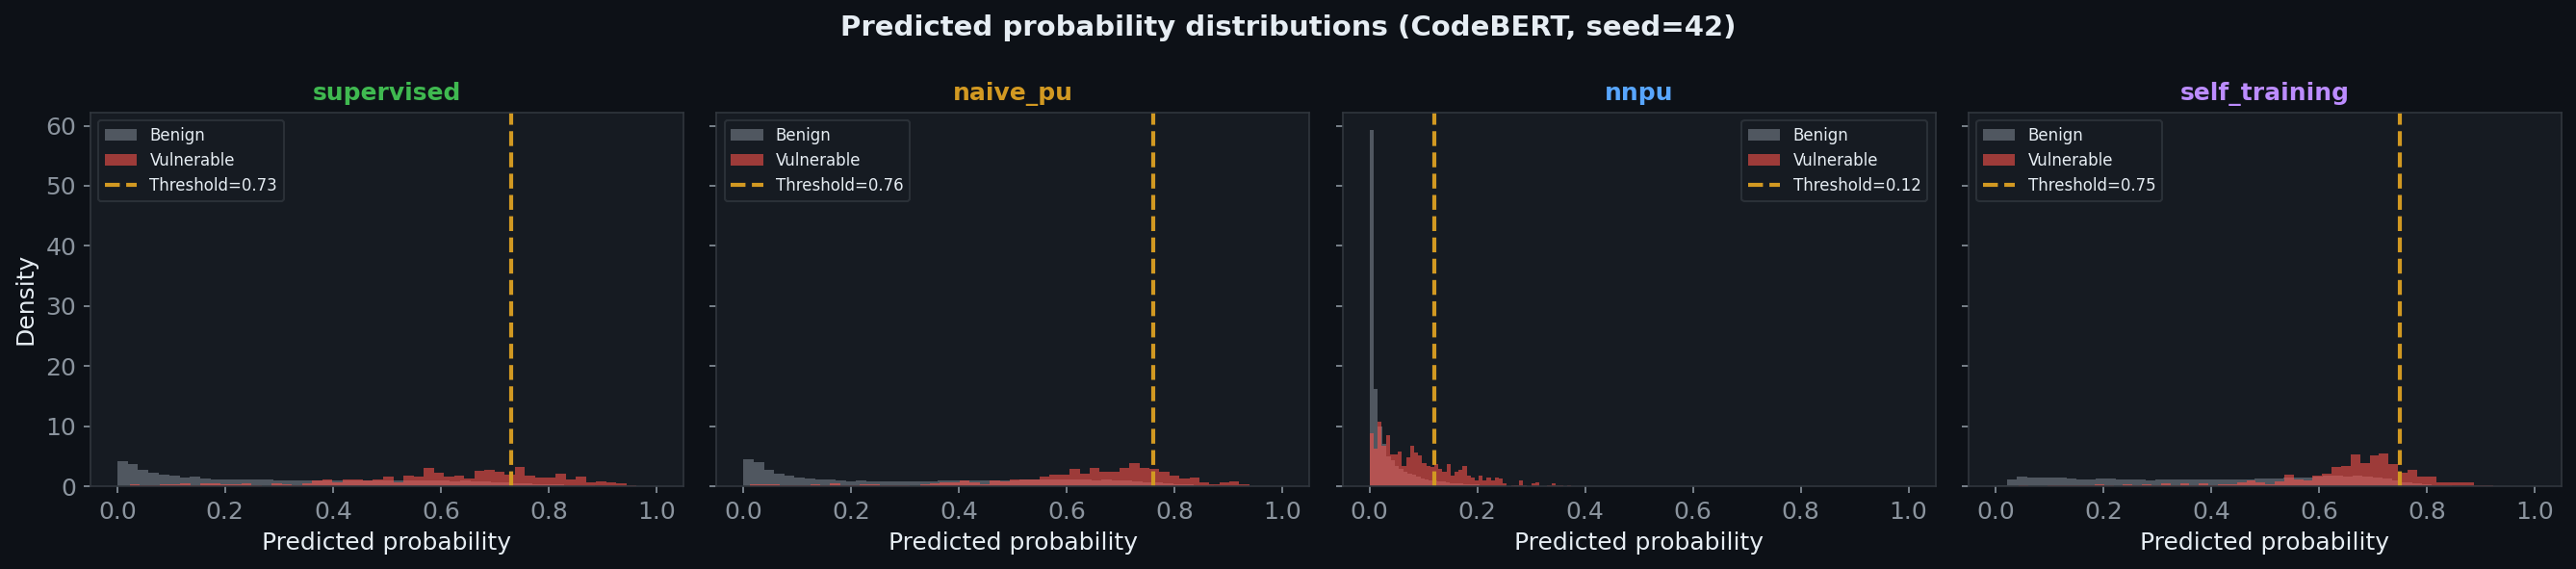

Note: nnPU outputs are compressed near 0. Its tuned threshold is ~0.11,
while other methods use thresholds of 0.6-0.8.


In [13]:
# Get test predictions from each method (seed=42)
test_data = load_split_embeddings(EMB_DIR, "test")
X_test = torch.tensor(test_data["embeddings"], dtype=torch.float32).to(device)
y_test = test_data["labels"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, method in zip(axes, ["supervised", "naive_pu", "nnpu", "self_training"]):
    model = cb_results[method][42]["model"]
    model.eval()
    with torch.no_grad():
        probs = model.predict_proba(X_test).cpu().numpy()
    
    ax.hist(probs[y_test == 0], bins=50, alpha=0.5, color="#8b949e", label="Benign", density=True)
    ax.hist(probs[y_test == 1], bins=50, alpha=0.6, color="#f85149", label="Vulnerable", density=True)
    
    # Find and mark tuned threshold
    val_data = load_split_embeddings(EMB_DIR, "valid")
    X_val = torch.tensor(val_data["embeddings"], dtype=torch.float32).to(device)
    thr, _ = find_best_threshold(model, X_val, val_data["labels"])
    ax.axvline(x=thr, color="#d29922", linestyle="--", linewidth=2, label=f"Threshold={thr:.2f}")
    
    ax.set_xlabel("Predicted probability")
    ax.set_title(method, fontsize=12, fontweight="bold", color=COLORS[method])
    ax.legend(fontsize=8)
    ax.set_xlim(-0.05, 1.05)

axes[0].set_ylabel("Density")
fig.suptitle("Predicted probability distributions (CodeBERT, seed=42)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb02_calibration_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

print("Note: nnPU outputs are compressed near 0. Its tuned threshold is ~0.11,")
print("while other methods use thresholds of 0.6-0.8.")

In [14]:
val_data = load_split_embeddings(EMB_DIR, "valid")
X_val = torch.tensor(val_data["embeddings"], dtype=torch.float32).to(device)

test_data = load_split_embeddings(EMB_DIR, "test")
X_test_t = torch.tensor(test_data["embeddings"], dtype=torch.float32).to(device)
y_test = test_data["labels"]

rows = []
for method in ["supervised", "naive_pu", "nnpu", "self_training"]:
    for seed in SEEDS:
        model = cb_results[method][seed]["model"]
        model.eval()
        
        # Tune threshold on val
        thr, val_f1 = find_best_threshold(model, X_val, val_data["labels"])
        
        # Test predictions
        with torch.no_grad():
            probs = model.predict_proba(X_test_t).cpu().numpy()
        preds = (probs >= thr).astype(int)
        
        f1 = f1_score(y_test, preds)
        auroc = roc_auc_score(y_test, probs)
        auprc = average_precision_score(y_test, probs)
        vds = compute_vds(probs, y_test)
        pw = compute_pairwise_accuracy(model, device)
        
        rows.append({
            "embedding": "CodeBERT", "method": method, "seed": seed,
            "threshold": round(thr, 2), "f1": round(f1, 4), "auroc": round(auroc, 4),
            "auprc": round(auprc, 4), "vds": round(vds, 4),
            "pairwise_acc": round(pw, 4) if pw >= 0 else None,
        })

df_cb = pd.DataFrame(rows)

# Summary table
print("=== CodeBERT Baseline Comparison (20% labeling, 3 seeds) ===\n")
summary = df_cb.groupby("method").agg(
    f1_mean=("f1", "mean"), f1_std=("f1", "std"),
    auroc_mean=("auroc", "mean"), auroc_std=("auroc", "std"),
    auprc_mean=("auprc", "mean"), auprc_std=("auprc", "std"),
    thr_mean=("threshold", "mean"),
).round(4)

for method in ["supervised", "naive_pu", "nnpu", "self_training"]:
    r = summary.loc[method]
    print(f"  {method:15s}  F1={r.f1_mean:.4f}+/-{r.f1_std:.4f}  "
          f"AUROC={r.auroc_mean:.4f}+/-{r.auroc_std:.4f}  "
          f"AUPRC={r.auprc_mean:.4f}  thr={r.thr_mean:.2f}")

=== CodeBERT Baseline Comparison (20% labeling, 3 seeds) ===

  supervised       F1=0.1567+/-0.0047  AUROC=0.8211+/-0.0017  AUPRC=0.0914  thr=0.74
  naive_pu         F1=0.1415+/-0.0045  AUROC=0.8160+/-0.0019  AUPRC=0.0856  thr=0.74
  nnpu             F1=0.1512+/-0.0070  AUROC=0.8124+/-0.0013  AUPRC=0.0849  thr=0.10
  self_training    F1=0.1338+/-0.0028  AUROC=0.8136+/-0.0020  AUPRC=0.0848  thr=0.74


In [15]:
VB_EMB_DIR = str(ROOT / "data" / "processed" / "embeddings_vulberta")
vb_results = {}

for seed in SEEDS:
    print(f"\n--- VulBERTa Seed {seed} ---")
    
    model, hist = train_supervised(embedding_dir=VB_EMB_DIR, seed=seed, device=device)
    torch.save(model.state_dict(), CKPT_DIR / f"nb02_supervised_vb_{seed}.pt")
    vb_results.setdefault("supervised", {})[seed] = {"model": model, "history": hist}
    print(f"  Supervised: best_epoch={hist['best_epoch']}, AUROC={hist['val_auroc'][hist['best_epoch']-1]:.4f}")
    
    model, hist = train_naive_pu(embedding_dir=VB_EMB_DIR, labeled_frac=FRAC,
                                  split_seed=seed, model_seed=seed, device=device)
    torch.save(model.state_dict(), CKPT_DIR / f"nb02_naive_pu_vb_{seed}.pt")
    vb_results.setdefault("naive_pu", {})[seed] = {"model": model, "history": hist}
    print(f"  Naive PU:   best_epoch={hist['best_epoch']}, AUROC={hist['val_auroc'][hist['best_epoch']-1]:.4f}")
    
    model, hist = train_nnpu(embedding_dir=VB_EMB_DIR, labeled_frac=FRAC,
                              split_seed=seed, model_seed=seed, prior=PRIOR, device=device)
    torch.save(model.state_dict(), CKPT_DIR / f"nb02_nnpu_vb_{seed}.pt")
    vb_results.setdefault("nnpu", {})[seed] = {"model": model, "history": hist}
    print(f"  nnPU:       best_epoch={hist['best_epoch']}, AUROC={hist['val_auroc'][hist['best_epoch']-1]:.4f}")
    
    model, hist = train_self_training(embedding_dir=VB_EMB_DIR, labeled_frac=FRAC,
                                       split_seed=seed, model_seed=seed, device=device)
    torch.save(model.state_dict(), CKPT_DIR / f"nb02_self_training_vb_{seed}.pt")
    vb_results.setdefault("self_training", {})[seed] = {"model": model, "history": hist}
    print(f"  Self-train: best_iter={hist['best_iteration']}, AUROC={hist['iter_val_auroc'][hist['best_iteration']]:.4f}")

# Evaluate VulBERTa
vb_val = load_split_embeddings(VB_EMB_DIR, "valid")
X_vb_val = torch.tensor(vb_val["embeddings"], dtype=torch.float32).to(device)
vb_test = load_split_embeddings(VB_EMB_DIR, "test")
X_vb_test = torch.tensor(vb_test["embeddings"], dtype=torch.float32).to(device)

vb_rows = []
for method in ["supervised", "naive_pu", "nnpu", "self_training"]:
    for seed in SEEDS:
        model = vb_results[method][seed]["model"]
        model.eval()
        thr, _ = find_best_threshold(model, X_vb_val, vb_val["labels"])
        with torch.no_grad():
            probs = model.predict_proba(X_vb_test).cpu().numpy()
        preds = (probs >= thr).astype(int)
        vb_rows.append({
            "embedding": "VulBERTa", "method": method, "seed": seed,
            "threshold": round(thr, 2), "f1": round(f1_score(vb_test["labels"], preds), 4),
            "auroc": round(roc_auc_score(vb_test["labels"], probs), 4),
            "auprc": round(average_precision_score(vb_test["labels"], probs), 4),
        })

df_vb = pd.DataFrame(vb_rows)
print("\n=== VulBERTa Baseline Comparison ===\n")
for method in ["supervised", "naive_pu", "nnpu", "self_training"]:
    m = df_vb[df_vb["method"] == method]
    print(f"  {method:15s}  F1={m.f1.mean():.4f}+/-{m.f1.std():.4f}  AUROC={m.auroc.mean():.4f}+/-{m.auroc.std():.4f}")


--- VulBERTa Seed 42 ---
  Supervised: best_epoch=12, AUROC=0.8097
  Naive PU:   best_epoch=18, AUROC=0.7967
  nnPU:       best_epoch=3, AUROC=0.8002
  Self-train: best_iter=0, AUROC=0.7967

--- VulBERTa Seed 123 ---
  Supervised: best_epoch=14, AUROC=0.8133
  Naive PU:   best_epoch=6, AUROC=0.7779
  nnPU:       best_epoch=2, AUROC=0.7795
  Self-train: best_iter=0, AUROC=0.7779

--- VulBERTa Seed 456 ---
  Supervised: best_epoch=11, AUROC=0.8119
  Naive PU:   best_epoch=16, AUROC=0.7968
  nnPU:       best_epoch=4, AUROC=0.7873
  Self-train: best_iter=0, AUROC=0.7968

=== VulBERTa Baseline Comparison ===

  supervised       F1=0.1835+/-0.0083  AUROC=0.8371+/-0.0011
  naive_pu         F1=0.1673+/-0.0109  AUROC=0.8136+/-0.0036
  nnpu             F1=0.1686+/-0.0040  AUROC=0.8106+/-0.0066
  self_training    F1=0.1673+/-0.0109  AUROC=0.8136+/-0.0036


Saved 24 rows to /Users/dbenson/mygit/stat3106/project/experiments/logs_reproduce/exp1_baseline.csv


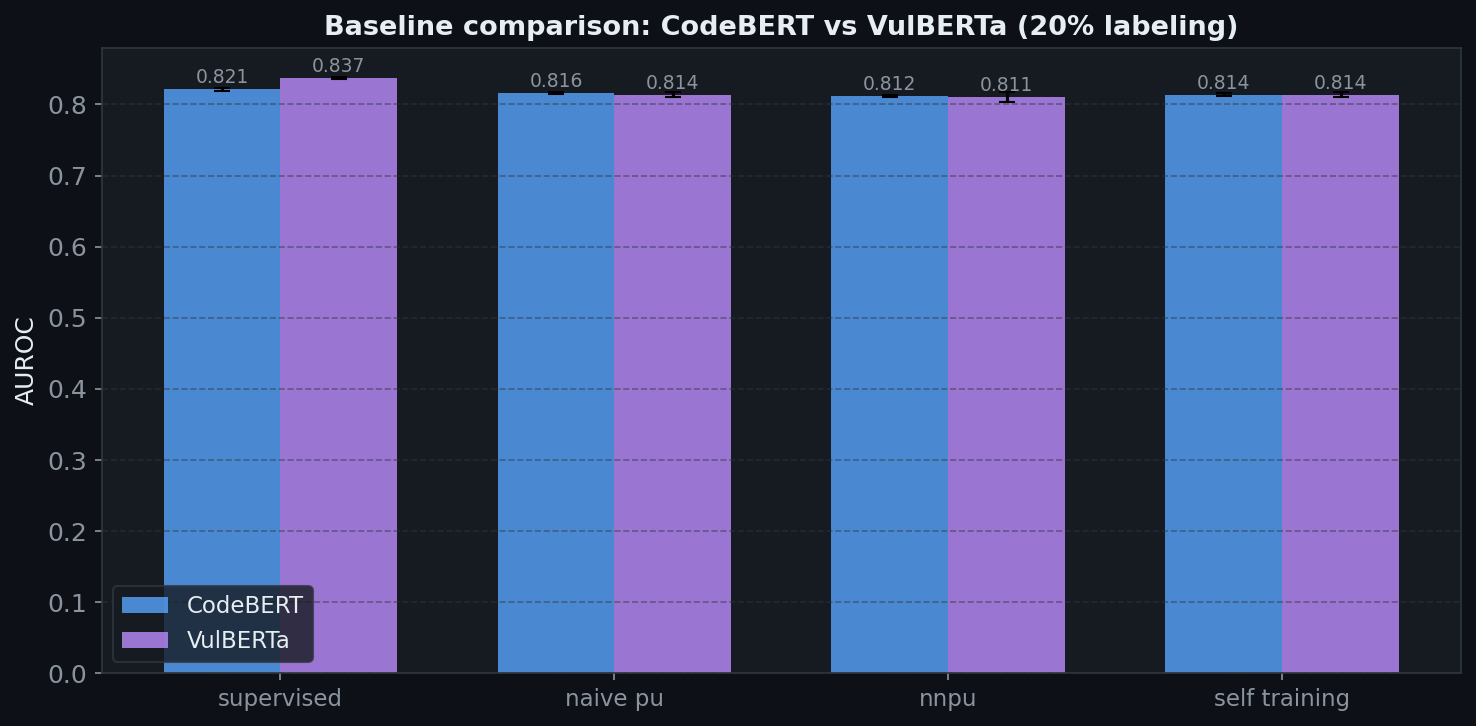


Method ranking is the same on both embedding models.
VulBERTa helps supervised more than PU methods (gap widens).


In [16]:
# Combine and save
df_all = pd.concat([df_cb, df_vb], ignore_index=True)

out_path = ROOT / "experiments" / "logs_reproduce" / "exp1_baseline.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
df_all.to_csv(out_path, index=False)
print(f"Saved {len(df_all)} rows to {out_path}")

# Side-by-side bar chart: CodeBERT vs VulBERTa AUROC
fig, ax = plt.subplots(figsize=(10, 5))
methods = ["supervised", "naive_pu", "nnpu", "self_training"]
x = np.arange(len(methods))
width = 0.35

cb_means = [df_cb[df_cb["method"] == m]["auroc"].mean() for m in methods]
cb_stds = [df_cb[df_cb["method"] == m]["auroc"].std() for m in methods]
vb_means = [df_vb[df_vb["method"] == m]["auroc"].mean() for m in methods]
vb_stds = [df_vb[df_vb["method"] == m]["auroc"].std() for m in methods]

bars1 = ax.bar(x - width/2, cb_means, width, yerr=cb_stds, label="CodeBERT",
               color="#58a6ff", alpha=0.8, capsize=4)
bars2 = ax.bar(x + width/2, vb_means, width, yerr=vb_stds, label="VulBERTa",
               color="#bc8cff", alpha=0.8, capsize=4)

ax.set_ylabel("AUROC")
ax.set_title("Baseline comparison: CodeBERT vs VulBERTa (20% labeling)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ") for m in methods], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--")

# Value labels
for bars, means in [(bars1, cb_means), (bars2, vb_means)]:
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, color="#8b949e")

plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb02_cb_vs_vb_auroc.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nMethod ranking is the same on both embedding models.")
print("VulBERTa helps supervised more than PU methods (gap widens).")

## 03 Labeling sweep

In [17]:
import sys, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from training import (
    train_supervised, train_naive_pu, train_nnpu, train_self_training,
    find_best_threshold, load_split_embeddings,
)
from evaluate import compute_vds, compute_pairwise_accuracy

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3", "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "grid.color": "#30363d", "grid.alpha": 0.5,
    "legend.facecolor": "#161b22", "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3", "font.size": 12, "figure.dpi": 150,
})

COLORS = {"supervised": "#3fb950", "naive_pu": "#d29922", "nnpu": "#58a6ff", "self_training": "#bc8cff"}
LABELS = {"supervised": "Supervised", "naive_pu": "Naive PU", "nnpu": "nnPU", "self_training": "Self-training"}
SEEDS = [42, 123, 456]
FRACS = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.80]
FRAC_TO_P = {0.02: 97, 0.05: 243, 0.10: 486, 0.20: 972, 0.30: 1458, 0.50: 2431, 0.80: 3889}
PRIOR = 0.0277
CKPT_DIR = ROOT / "checkpoints" / "reproduce"
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

Device: mps


In [18]:
def run_sweep(emb_dir, emb_name, seeds=SEEDS, fracs=FRACS):
    """Run labeling sweep. Returns DataFrame with all results."""
    val = load_split_embeddings(emb_dir, "valid")
    test = load_split_embeddings(emb_dir, "test")
    X_val = torch.tensor(val["embeddings"], dtype=torch.float32).to(device)
    X_test = torch.tensor(test["embeddings"], dtype=torch.float32).to(device)
    
    # Get supervised ceiling (once, 3 seeds)
    rows = []
    for seed in seeds:
        model, _ = train_supervised(embedding_dir=emb_dir, seed=seed, device=device)
        thr, _ = find_best_threshold(model, X_val, val["labels"])
        with torch.no_grad():
            probs = model.predict_proba(X_test).cpu().numpy()
        preds = (probs >= thr).astype(int)
        rows.append({
            "embedding": emb_name, "method": "supervised", "labeled_frac": 1.0,
            "seed": seed, "p_count": 4862,
            "f1": round(f1_score(test["labels"], preds), 4),
            "auroc": round(roc_auc_score(test["labels"], probs), 4),
            "auprc": round(average_precision_score(test["labels"], probs), 4),
        })
    print(f"  Supervised ceiling done ({emb_name})")
    
    # PU methods at each fraction
    methods = {
        "naive_pu": lambda s, f: train_naive_pu(emb_dir, f, s, s, device=device),
        "nnpu": lambda s, f: train_nnpu(emb_dir, f, s, s, prior=PRIOR, device=device),
        "self_training": lambda s, f: train_self_training(emb_dir, f, s, s, device=device),
    }
    
    total = len(fracs) * len(seeds) * len(methods)
    done = 0
    for frac in fracs:
        for seed in seeds:
            for method_name, train_fn in methods.items():
                model, hist = train_fn(seed, frac)
                thr, _ = find_best_threshold(model, X_val, val["labels"])
                with torch.no_grad():
                    probs = model.predict_proba(X_test).cpu().numpy()
                preds = (probs >= thr).astype(int)
                
                rows.append({
                    "embedding": emb_name, "method": method_name,
                    "labeled_frac": frac, "seed": seed,
                    "p_count": FRAC_TO_P.get(frac, int(frac * 4862)),
                    "f1": round(f1_score(test["labels"], preds), 4),
                    "auroc": round(roc_auc_score(test["labels"], probs), 4),
                    "auprc": round(average_precision_score(test["labels"], probs), 4),
                })
                done += 1
                if done % 9 == 0:
                    print(f"  {emb_name}: {done}/{total} runs complete (frac={frac})")
    
    return pd.DataFrame(rows)

In [19]:
print("Running CodeBERT sweep (66 runs)...")
cb_emb_dir = str(ROOT / "data" / "processed" / "embeddings")
df_cb = run_sweep(cb_emb_dir, "CodeBERT")
print(f"CodeBERT: {len(df_cb)} rows")

Running CodeBERT sweep (66 runs)...
  Supervised ceiling done (CodeBERT)
  CodeBERT: 9/63 runs complete (frac=0.02)
  CodeBERT: 18/63 runs complete (frac=0.05)
  CodeBERT: 27/63 runs complete (frac=0.1)
  CodeBERT: 36/63 runs complete (frac=0.2)
  CodeBERT: 45/63 runs complete (frac=0.3)
  CodeBERT: 54/63 runs complete (frac=0.5)
  CodeBERT: 63/63 runs complete (frac=0.8)
CodeBERT: 66 rows


In [20]:
print("Running VulBERTa sweep (66 runs)...")
vb_emb_dir = str(ROOT / "data" / "processed" / "embeddings_vulberta")
df_vb = run_sweep(vb_emb_dir, "VulBERTa")
print(f"VulBERTa: {len(df_vb)} rows")

Running VulBERTa sweep (66 runs)...
  Supervised ceiling done (VulBERTa)
  VulBERTa: 9/63 runs complete (frac=0.02)
  VulBERTa: 18/63 runs complete (frac=0.05)
  VulBERTa: 27/63 runs complete (frac=0.1)
  VulBERTa: 36/63 runs complete (frac=0.2)
  VulBERTa: 45/63 runs complete (frac=0.3)
  VulBERTa: 54/63 runs complete (frac=0.5)
  VulBERTa: 63/63 runs complete (frac=0.8)
VulBERTa: 66 rows


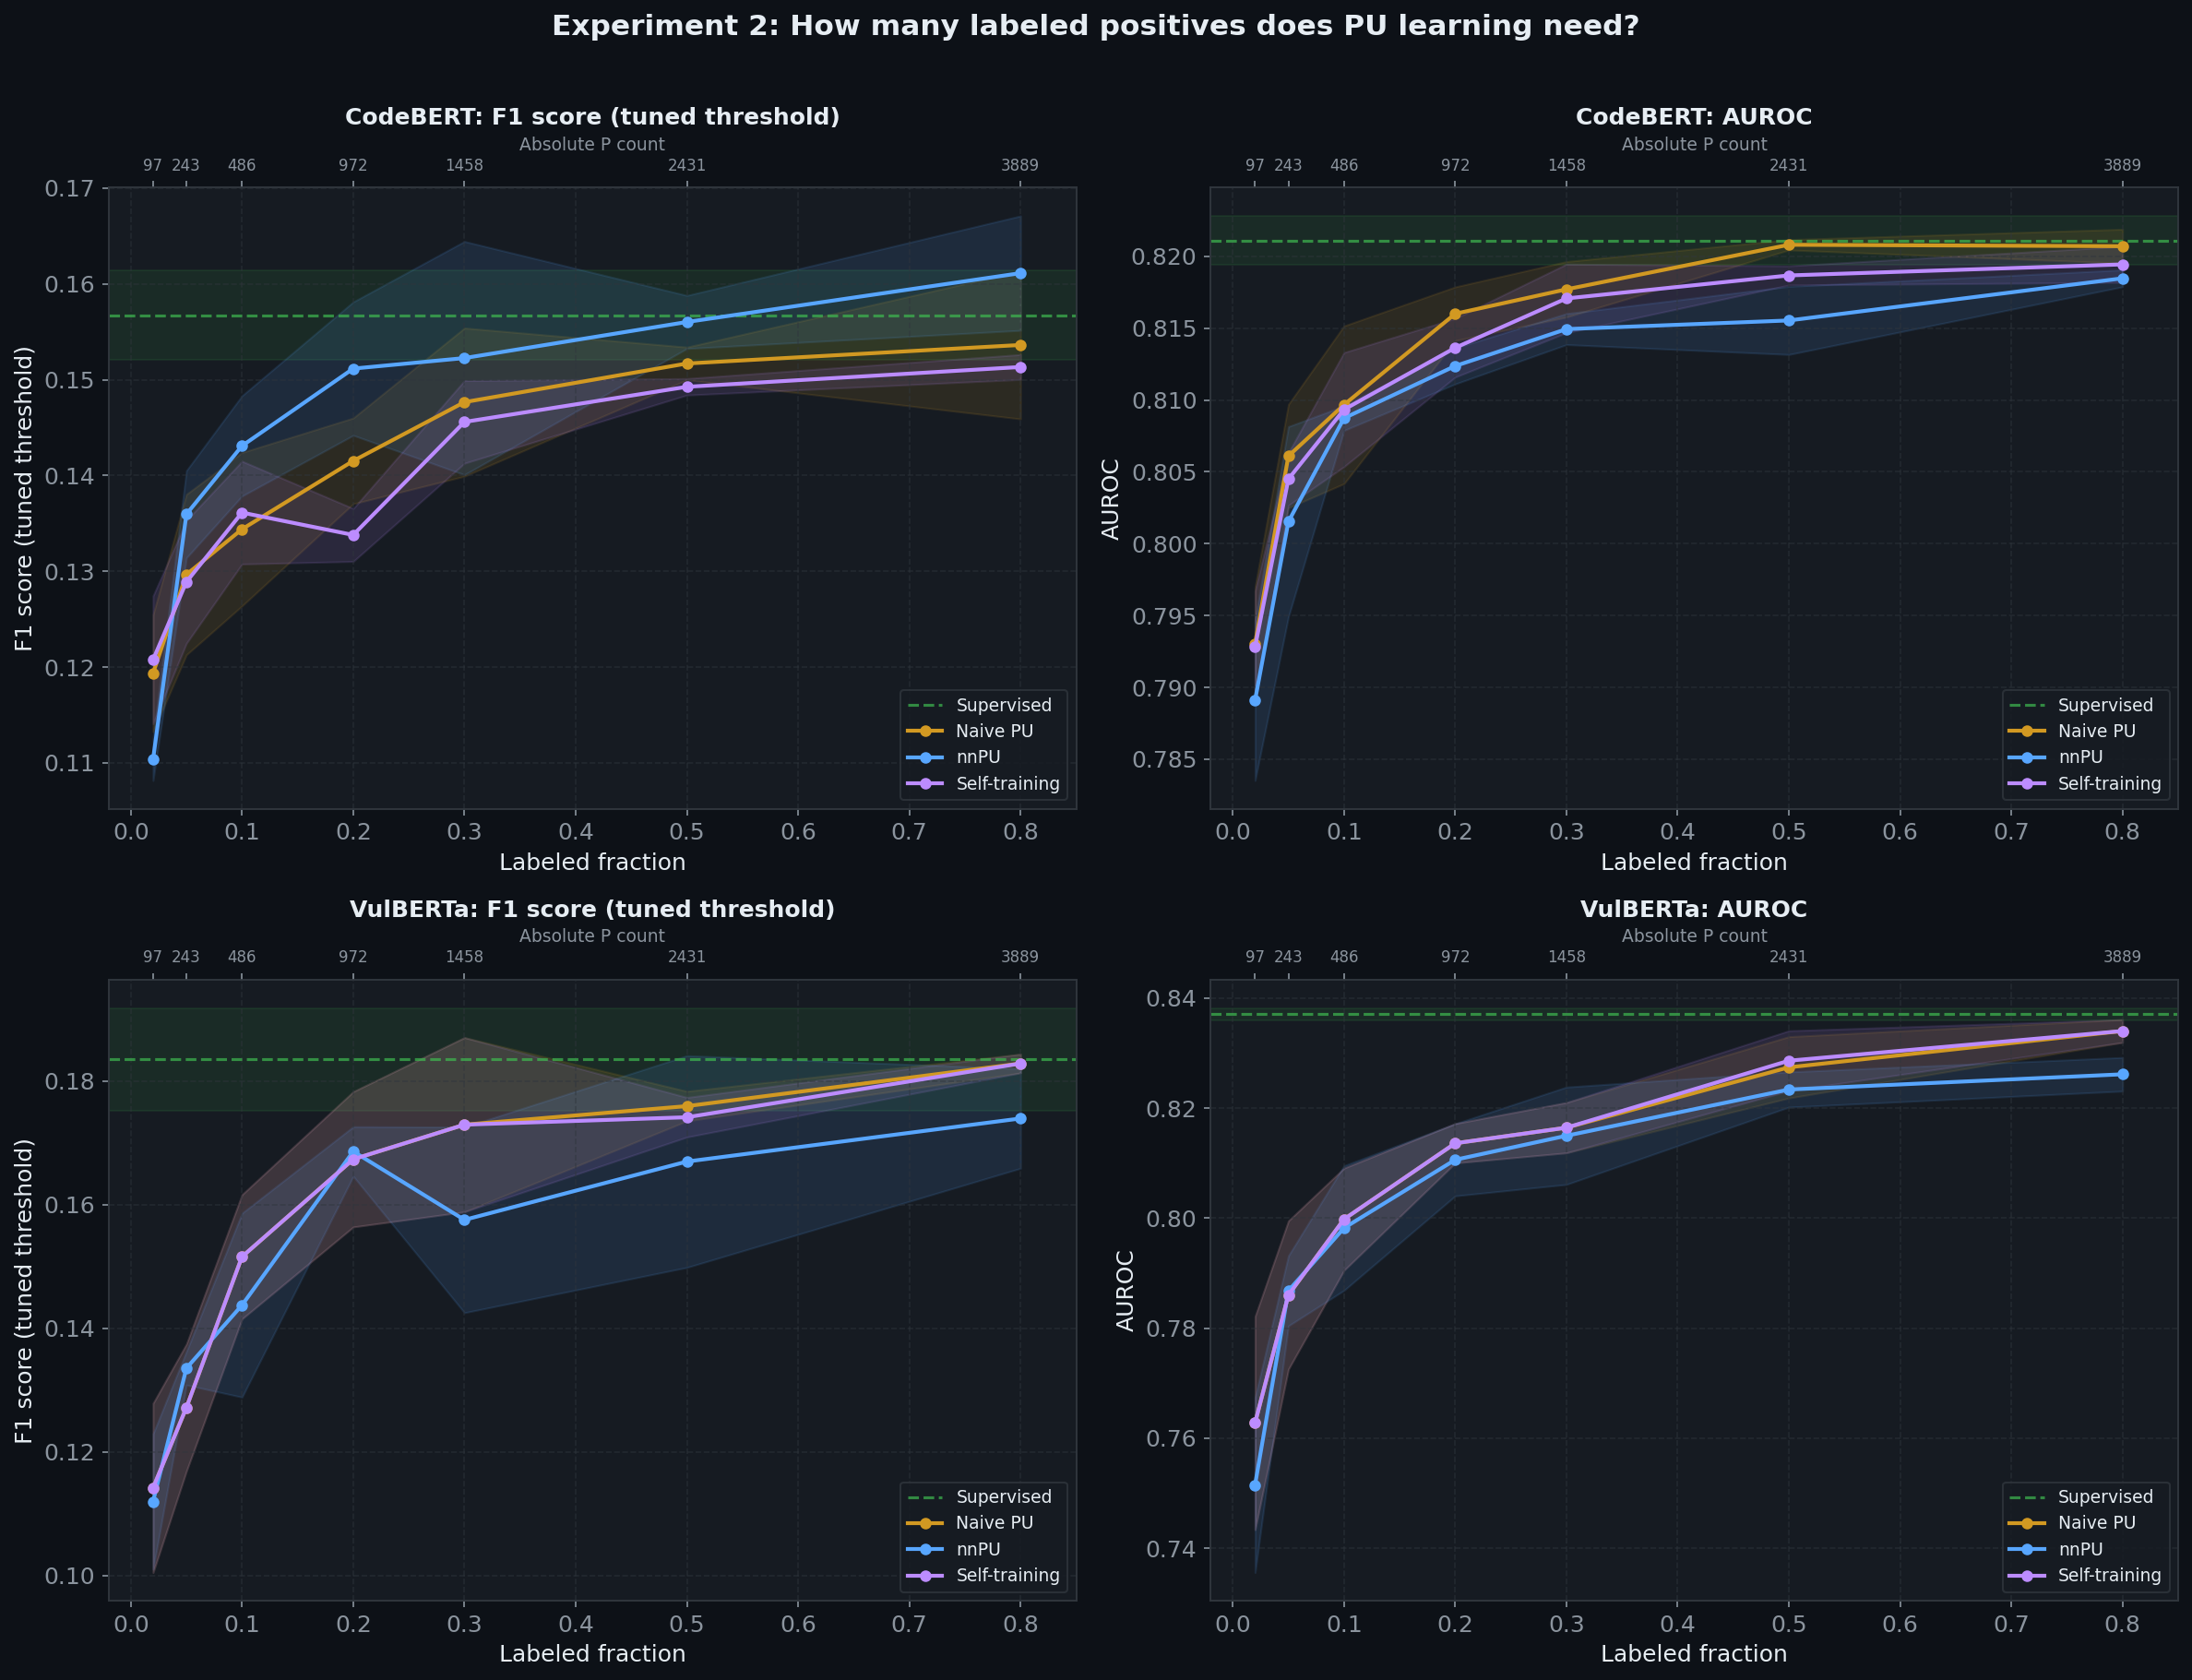

In [21]:
def plot_labeling_curve(df, emb_name, axes_row):
    """Plot F1 and AUROC labeling curves for one embedding model."""
    # Supervised ceiling
    sup = df[df["method"] == "supervised"]
    sup_f1_mean = sup["f1"].mean()
    sup_auroc_mean = sup["auroc"].mean()
    sup_f1_std = sup["f1"].std()
    sup_auroc_std = sup["auroc"].std()
    
    pu_methods = ["naive_pu", "nnpu", "self_training"]
    
    for ax, metric, sup_mean, sup_std, ylabel in [
        (axes_row[0], "f1", sup_f1_mean, sup_f1_std, "F1 score (tuned threshold)"),
        (axes_row[1], "auroc", sup_auroc_mean, sup_auroc_std, "AUROC"),
    ]:
        ax.set_xlim(-0.02, 0.85)
        
        # Supervised ceiling
        ax.axhline(y=sup_mean, color=COLORS["supervised"], linestyle="--", alpha=0.7, label="Supervised")
        ax.fill_between([-0.02, 0.85], sup_mean - sup_std, sup_mean + sup_std,
                        color=COLORS["supervised"], alpha=0.1)
        
        for method in pu_methods:
            md = df[df["method"] == method]
            fracs = sorted(md["labeled_frac"].unique())
            means = [md[md["labeled_frac"] == f][metric].mean() for f in fracs]
            stds = [md[md["labeled_frac"] == f][metric].std() for f in fracs]
            means, stds = np.array(means), np.array(stds)
            
            ax.plot(fracs, means, "o-", color=COLORS[method], label=LABELS[method],
                    markersize=5, linewidth=2)
            ax.fill_between(fracs, means - stds, means + stds, color=COLORS[method], alpha=0.12)
        
        ax.set_xlabel("Labeled fraction")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{emb_name}: {ylabel}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=9, loc="lower right")
        ax.grid(True, linestyle="--")
        
        # Secondary x-axis with P counts
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        tick_fracs = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.80]
        ax2.set_xticks(tick_fracs)
        ax2.set_xticklabels([str(FRAC_TO_P[f]) for f in tick_fracs], fontsize=8)
        ax2.set_xlabel("Absolute P count", fontsize=9, color="#8b949e")
        ax2.tick_params(colors="#8b949e")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_labeling_curve(df_cb, "CodeBERT", axes[0])
plot_labeling_curve(df_vb, "VulBERTa", axes[1])

fig.suptitle("Experiment 2: How many labeled positives does PU learning need?",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb03_labeling_curves.png", dpi=300, bbox_inches="tight")
plt.show()

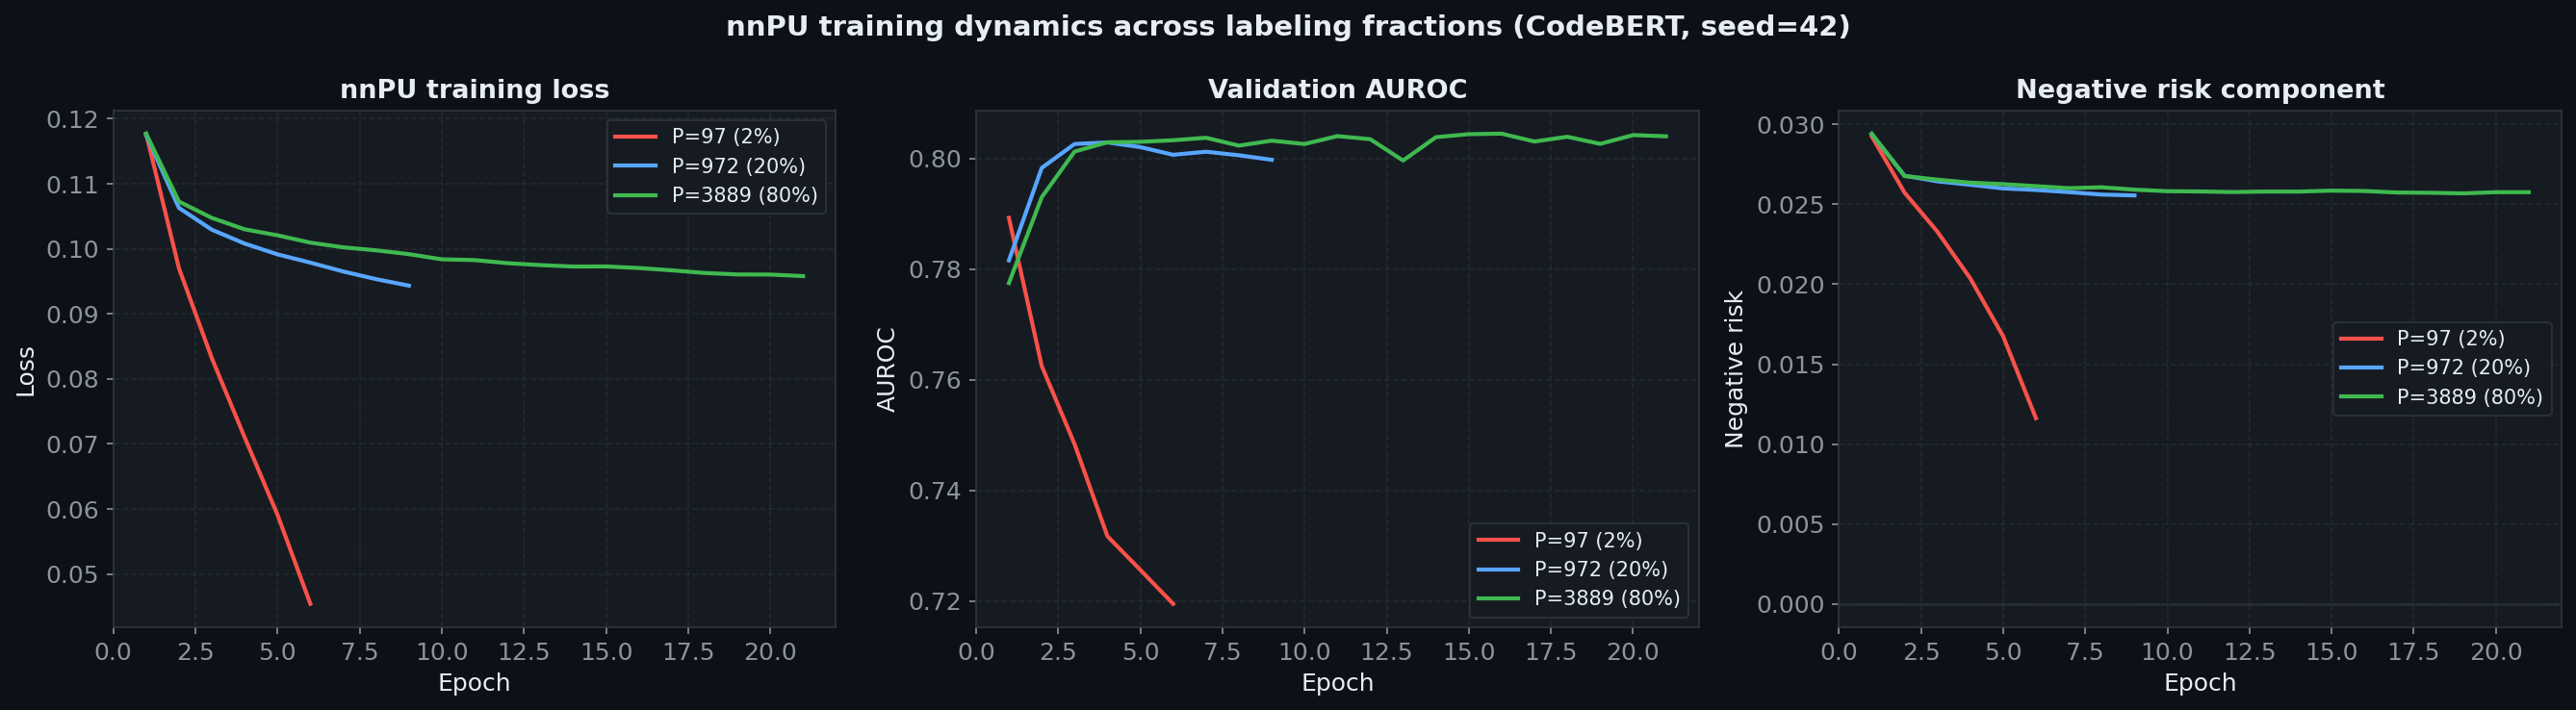

In [22]:
# Train nnPU at extreme fractions to compare training dynamics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

extreme_histories = {}
for frac, color, ls in [(0.02, "#f85149", "-"), (0.20, "#58a6ff", "-"), (0.80, "#3fb950", "-")]:
    model, hist = train_nnpu(embedding_dir=cb_emb_dir, labeled_frac=frac,
                              split_seed=42, model_seed=42, prior=PRIOR, device=device)
    extreme_histories[frac] = hist
    p_count = FRAC_TO_P[frac]
    label = f"P={p_count} ({frac:.0%})"
    
    epochs = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(epochs, hist["train_loss"], color=color, label=label, linewidth=2, linestyle=ls)
    axes[1].plot(epochs, hist["val_auroc"], color=color, label=label, linewidth=2, linestyle=ls)
    axes[2].plot(epochs, hist["negative_risk"], color=color, label=label, linewidth=2, linestyle=ls)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("nnPU training loss", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUROC")
axes[1].set_title("Validation AUROC", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Negative risk")
axes[2].set_title("Negative risk component", fontsize=13, fontweight="bold")
axes[2].axhline(y=0, color="#30363d", linestyle="-", alpha=0.5)

for ax in axes:
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--")

fig.suptitle("nnPU training dynamics across labeling fractions (CodeBERT, seed=42)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb03_extreme_fractions.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
# Save CSVs
out_cb = ROOT / "experiments" / "logs_reproduce" / "exp2_labeling.csv"
out_vb = ROOT / "experiments" / "logs_reproduce" / "exp2_labeling_vulberta.csv"
df_cb.to_csv(out_cb, index=False)
df_vb.to_csv(out_vb, index=False)
print(f"Saved {len(df_cb)} CodeBERT rows to {out_cb}")
print(f"Saved {len(df_vb)} VulBERTa rows to {out_vb}")

# Summary table: F1 mean across seeds at each fraction
print("\n=== CodeBERT F1 (mean, 3 seeds) ===")
pu = df_cb[df_cb["method"] != "supervised"]
pivot = pu.pivot_table(index="labeled_frac", columns="method", values="f1", aggfunc="mean")
print(pivot.round(4).to_string())

print("\n=== VulBERTa F1 (mean, 3 seeds) ===")
pu_vb = df_vb[df_vb["method"] != "supervised"]
pivot_vb = pu_vb.pivot_table(index="labeled_frac", columns="method", values="f1", aggfunc="mean")
print(pivot_vb.round(4).to_string())

Saved 66 CodeBERT rows to /Users/dbenson/mygit/stat3106/project/experiments/logs_reproduce/exp2_labeling.csv
Saved 66 VulBERTa rows to /Users/dbenson/mygit/stat3106/project/experiments/logs_reproduce/exp2_labeling_vulberta.csv

=== CodeBERT F1 (mean, 3 seeds) ===
method        naive_pu    nnpu  self_training
labeled_frac                                 
0.02            0.1194  0.1104         0.1208
0.05            0.1297  0.1360         0.1289
0.10            0.1344  0.1431         0.1361
0.20            0.1415  0.1512         0.1338
0.30            0.1477  0.1523         0.1456
0.50            0.1517  0.1560         0.1493
0.80            0.1536  0.1611         0.1513

=== VulBERTa F1 (mean, 3 seeds) ===
method        naive_pu    nnpu  self_training
labeled_frac                                 
0.02            0.1142  0.1120         0.1142
0.05            0.1272  0.1335         0.1272
0.10            0.1516  0.1437         0.1516
0.20            0.1673  0.1686         0.1673
0.30     

## 04 Prior sensitivity

In [24]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from training import train_nnpu, find_best_threshold, load_split_embeddings

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3", "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "grid.color": "#30363d", "grid.alpha": 0.5,
    "legend.facecolor": "#161b22", "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3", "font.size": 12, "figure.dpi": 150,
})

EMB_DIR = str(ROOT / "data" / "processed" / "embeddings")
SEEDS = [42, 123, 456]
TRUE_PRIOR = 0.0277
PRIORS = [0.0139, 0.0208, 0.0277, 0.0346, 0.0416, 0.0554]
PRIOR_LABELS = {0.0139: "0.5x", 0.0208: "0.75x", 0.0277: "1.0x",
                0.0346: "1.25x", 0.0416: "1.5x", 0.0554: "2.0x"}

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

In [25]:
val = load_split_embeddings(EMB_DIR, "valid")
test = load_split_embeddings(EMB_DIR, "test")
X_val = torch.tensor(val["embeddings"], dtype=torch.float32).to(device)
X_test = torch.tensor(test["embeddings"], dtype=torch.float32).to(device)

rows = []
for prior in PRIORS:
    for seed in SEEDS:
        model, hist = train_nnpu(EMB_DIR, labeled_frac=0.20, split_seed=seed,
                                  model_seed=seed, prior=prior, device=device)
        thr, _ = find_best_threshold(model, X_val, val["labels"])
        with torch.no_grad():
            probs = model.predict_proba(X_test).cpu().numpy()
        preds = (probs >= thr).astype(int)
        
        rows.append({
            "prior": prior, "prior_mult": PRIOR_LABELS[prior], "seed": seed,
            "threshold": round(thr, 2),
            "f1": round(f1_score(test["labels"], preds), 4),
            "auroc": round(roc_auc_score(test["labels"], probs), 4),
            "auprc": round(average_precision_score(test["labels"], probs), 4),
        })
    print(f"  Prior {PRIOR_LABELS[prior]} ({prior:.4f}): done")

df = pd.DataFrame(rows)
print(f"\n{len(df)} runs complete")

  Prior 0.5x (0.0139): done
  Prior 0.75x (0.0208): done
  Prior 1.0x (0.0277): done
  Prior 1.25x (0.0346): done
  Prior 1.5x (0.0416): done
  Prior 2.0x (0.0554): done

18 runs complete


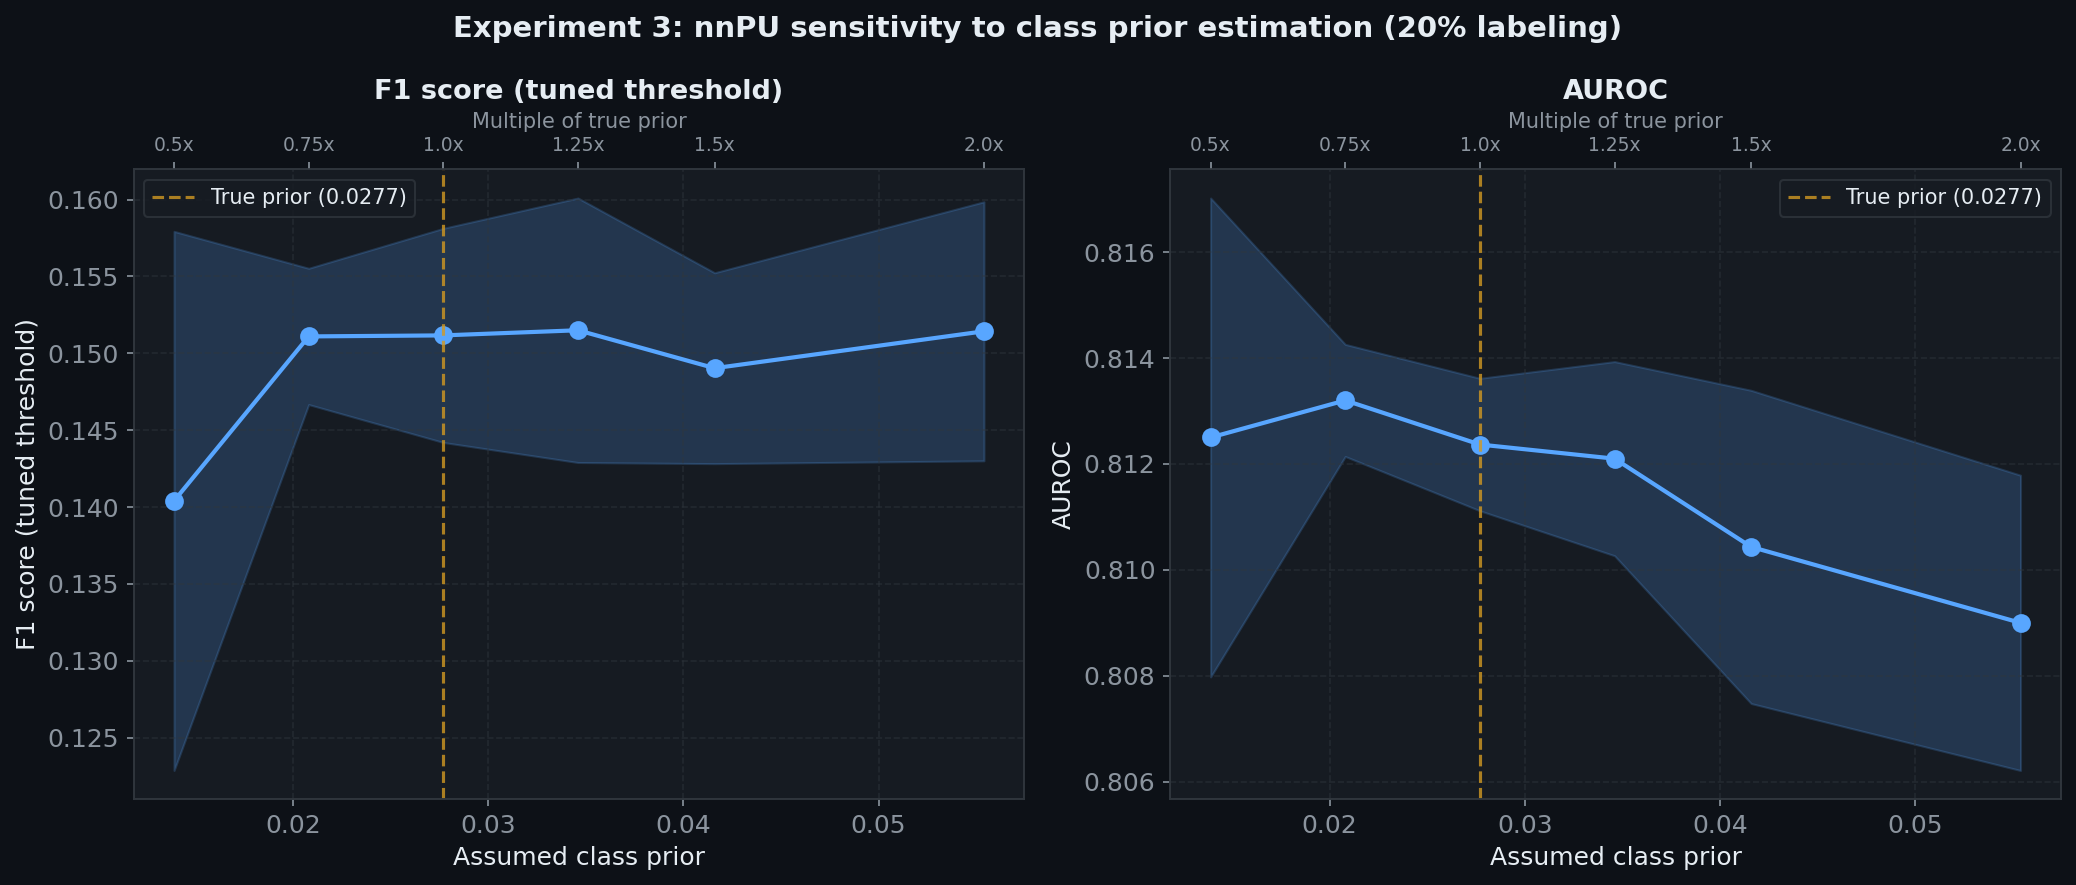


=== Prior sensitivity summary ===

   0.5x (pi=0.0139): F1=0.1404+/-0.0175  AUROC=0.8125+/-0.0045
  0.75x (pi=0.0208): F1=0.1511+/-0.0044  AUROC=0.8132+/-0.0011
   1.0x (pi=0.0277): F1=0.1512+/-0.0070  AUROC=0.8124+/-0.0013
  1.25x (pi=0.0346): F1=0.1515+/-0.0086  AUROC=0.8121+/-0.0018
   1.5x (pi=0.0416): F1=0.1490+/-0.0062  AUROC=0.8104+/-0.0030
   2.0x (pi=0.0554): F1=0.1514+/-0.0084  AUROC=0.8090+/-0.0028


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel in [(axes[0], "f1", "F1 score (tuned threshold)"),
                            (axes[1], "auroc", "AUROC")]:
    means = df.groupby("prior")[metric].mean()
    stds = df.groupby("prior")[metric].std()
    priors = means.index.values
    
    ax.plot(priors, means.values, "o-", color="#58a6ff", markersize=8, linewidth=2)
    ax.fill_between(priors, means.values - stds.values, means.values + stds.values,
                    color="#58a6ff", alpha=0.2)
    ax.axvline(x=TRUE_PRIOR, color="#d29922", linestyle="--", alpha=0.8,
               label=f"True prior ({TRUE_PRIOR})")
    
    ax.set_xlabel("Assumed class prior")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--")
    
    # Secondary axis with multiplier labels
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(priors)
    ax2.set_xticklabels([PRIOR_LABELS[p] for p in priors], fontsize=9)
    ax2.set_xlabel("Multiple of true prior", fontsize=10, color="#8b949e")
    ax2.tick_params(colors="#8b949e")

fig.suptitle("Experiment 3: nnPU sensitivity to class prior estimation (20% labeling)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb04_prior_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

# Print summary
print("\n=== Prior sensitivity summary ===\n")
for prior in PRIORS:
    m = df[df["prior"] == prior]
    print(f"  {PRIOR_LABELS[prior]:>5s} (pi={prior:.4f}): F1={m.f1.mean():.4f}+/-{m.f1.std():.4f}  "
          f"AUROC={m.auroc.mean():.4f}+/-{m.auroc.std():.4f}")

In [27]:
# Save CSV
out_path = ROOT / "experiments" / "logs_reproduce" / "exp3_prior.csv"
df.to_csv(out_path, index=False)
print(f"Saved {len(df)} rows to {out_path}")

Saved 18 rows to /Users/dbenson/mygit/stat3106/project/experiments/logs_reproduce/exp3_prior.csv


## 05 Ablations

In [28]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, roc_auc_score

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from training import train_nnpu, train_self_training, find_best_threshold, load_split_embeddings

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3", "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "grid.color": "#30363d", "grid.alpha": 0.5,
    "legend.facecolor": "#161b22", "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3", "font.size": 12, "figure.dpi": 150,
})

EMB_DIR = str(ROOT / "data" / "processed" / "embeddings")
PRIOR = 0.0277
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

In [29]:
val = load_split_embeddings(EMB_DIR, "valid")
test = load_split_embeddings(EMB_DIR, "test")
X_val = torch.tensor(val["embeddings"], dtype=torch.float32).to(device)
X_test = torch.tensor(test["embeddings"], dtype=torch.float32).to(device)

split_seeds = [42, 123, 456]
model_seeds = [42, 123, 456]

var_rows = []
for method_name, train_fn in [
    ("nnpu", lambda ss, ms: train_nnpu(EMB_DIR, 0.20, ss, ms, PRIOR, device=device)),
    ("self_training", lambda ss, ms: train_self_training(EMB_DIR, 0.20, ss, ms, device=device)),
]:
    for split_seed in split_seeds:
        for model_seed in model_seeds:
            model, hist = train_fn(split_seed, model_seed)
            thr, _ = find_best_threshold(model, X_val, val["labels"])
            with torch.no_grad():
                probs = model.predict_proba(X_test).cpu().numpy()
            auroc = roc_auc_score(test["labels"], probs)
            
            var_rows.append({
                "method": method_name, "split_seed": split_seed,
                "model_seed": model_seed, "auroc": round(auroc, 4),
            })
    print(f"  {method_name}: 9 runs done")

df_var = pd.DataFrame(var_rows)
print(f"\n{len(df_var)} variance decomposition runs complete")

  nnpu: 9 runs done
  self_training: 9 runs done

18 variance decomposition runs complete


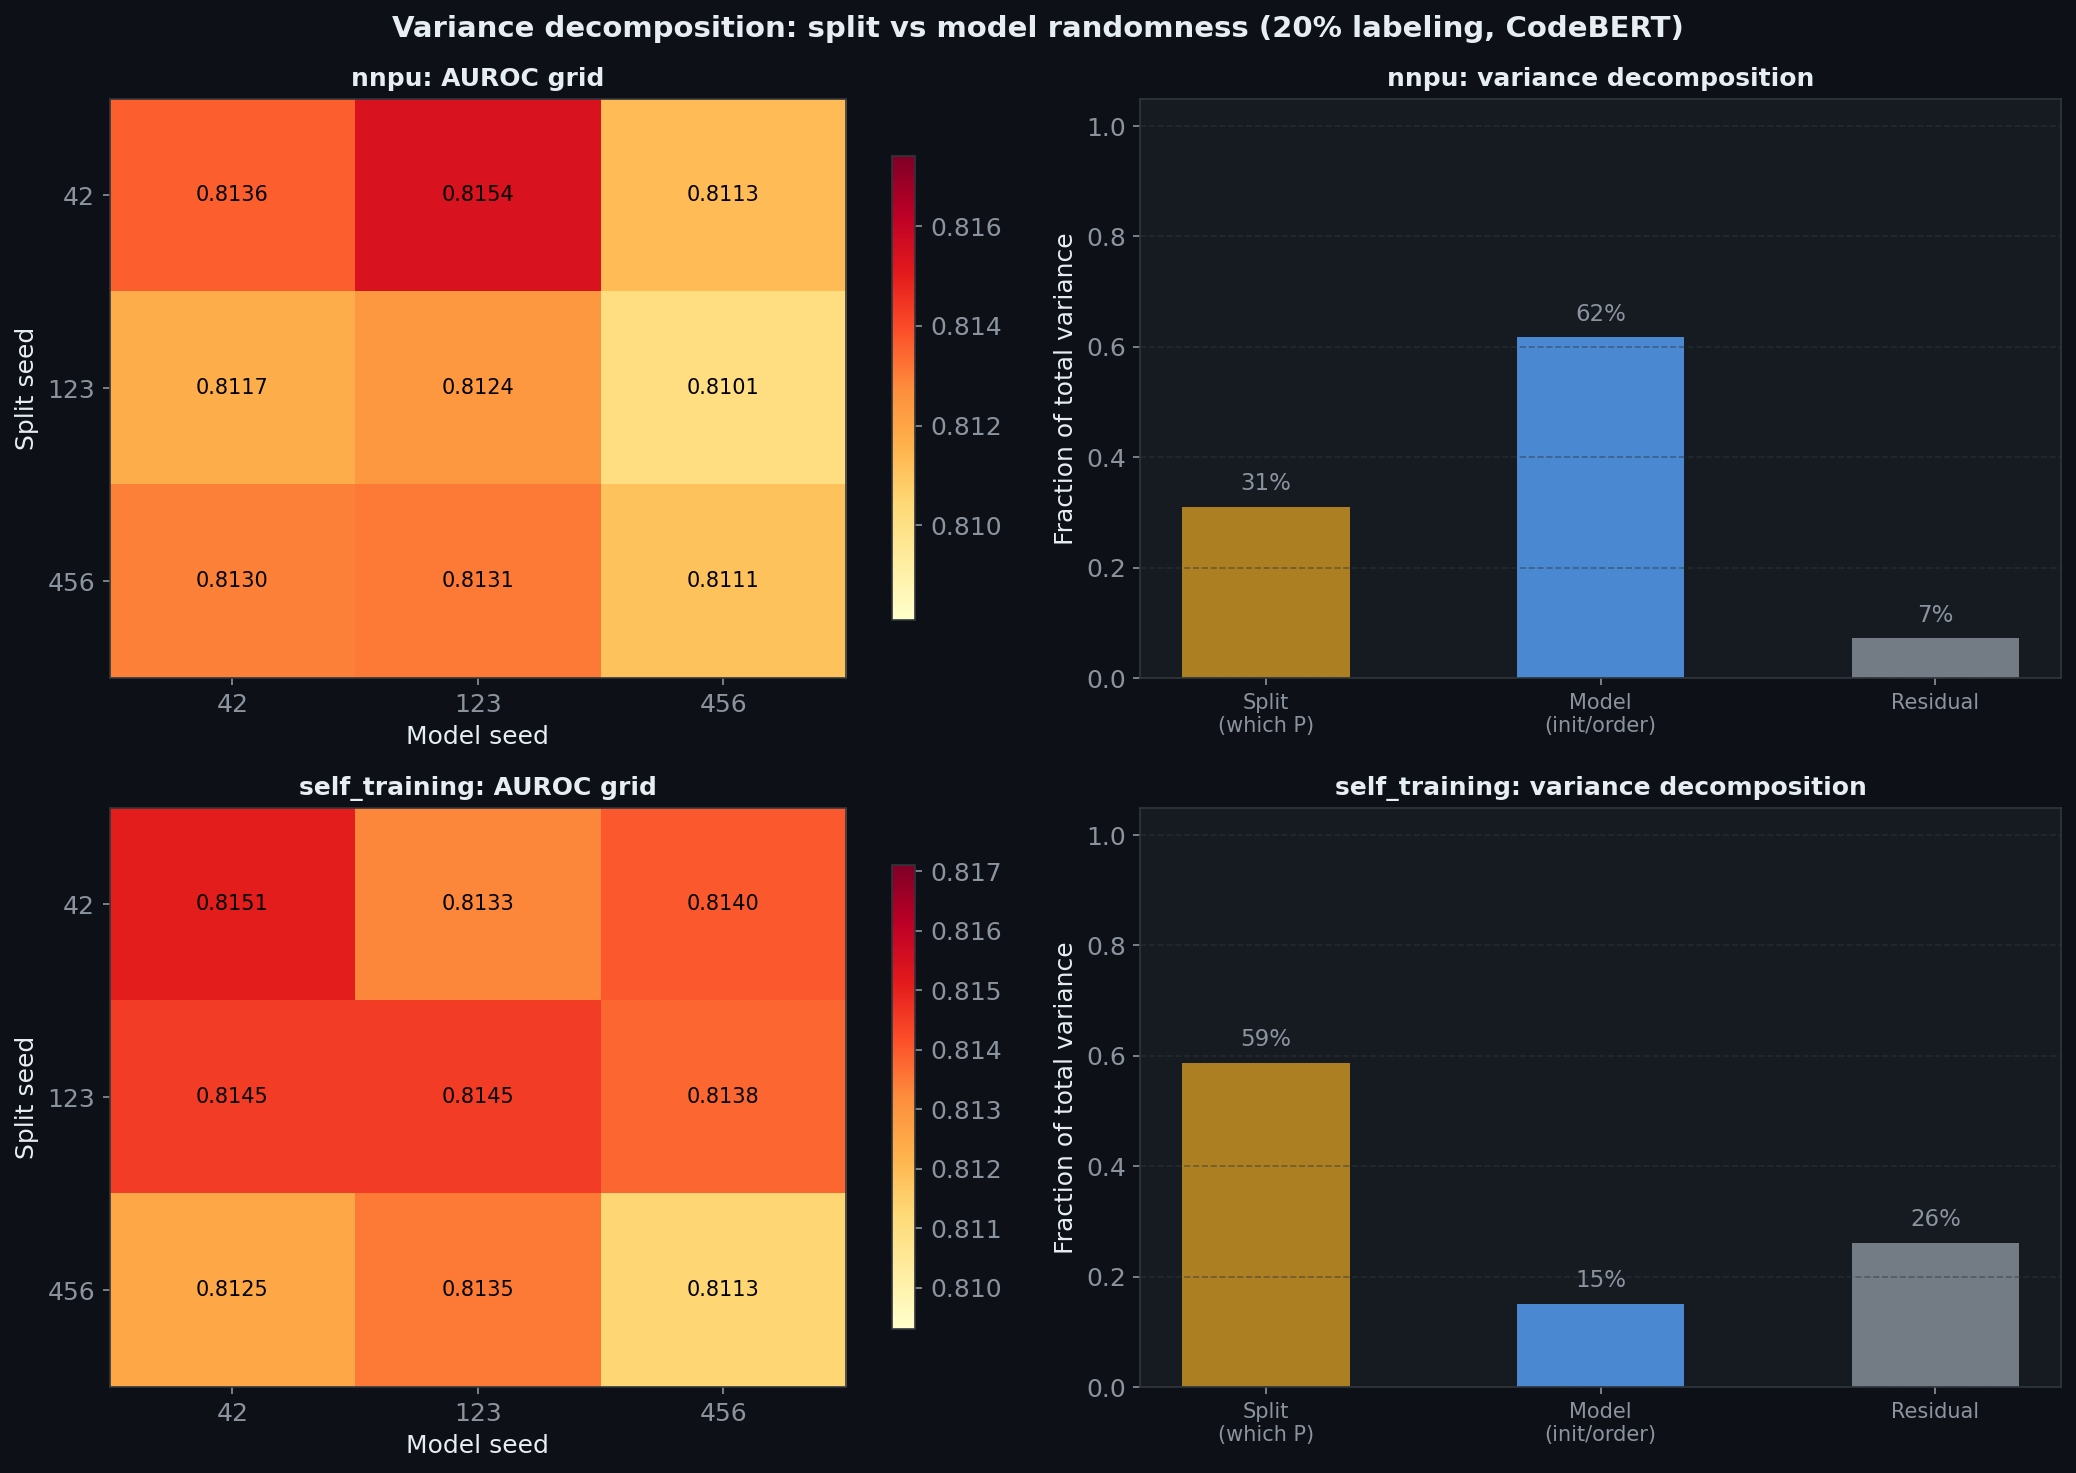

In [30]:
# ANOVA decomposition + heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, method in enumerate(["nnpu", "self_training"]):
    md = df_var[df_var["method"] == method]
    
    # Heatmap of AUROC values
    ax = axes[i][0]
    grid = md.pivot(index="split_seed", columns="model_seed", values="auroc")
    im = ax.imshow(grid.values, cmap="YlOrRd", aspect="auto", vmin=grid.values.min() - 0.002, vmax=grid.values.max() + 0.002)
    ax.set_xticks(range(3)); ax.set_xticklabels(model_seeds)
    ax.set_yticks(range(3)); ax.set_yticklabels(split_seeds)
    ax.set_xlabel("Model seed"); ax.set_ylabel("Split seed")
    ax.set_title(f"{method}: AUROC grid", fontsize=12, fontweight="bold")
    
    for r in range(3):
        for c in range(3):
            ax.text(c, r, f"{grid.values[r, c]:.4f}", ha="center", va="center", fontsize=10, color="black")
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # ANOVA decomposition bar chart
    ax = axes[i][1]
    values = md["auroc"].values
    grand_mean = values.mean()
    
    split_means = md.groupby("split_seed")["auroc"].mean()
    model_means = md.groupby("model_seed")["auroc"].mean()
    
    ss_split = 3 * ((split_means - grand_mean) ** 2).sum()
    ss_model = 3 * ((model_means - grand_mean) ** 2).sum()
    ss_total = ((values - grand_mean) ** 2).sum()
    ss_residual = ss_total - ss_split - ss_model
    
    fracs = [ss_split / ss_total, ss_model / ss_total, ss_residual / ss_total] if ss_total > 0 else [0, 0, 0]
    
    bars = ax.bar([0, 1, 2], fracs, color=["#d29922", "#58a6ff", "#8b949e"], alpha=0.8, width=0.5)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Split\n(which P)", "Model\n(init/order)", "Residual"], fontsize=10)
    ax.set_ylabel("Fraction of total variance")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{method}: variance decomposition", fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--")
    
    for bar, frac in zip(bars, fracs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f"{frac:.0%}", ha="center", fontsize=11, color="#8b949e")

fig.suptitle("Variance decomposition: split vs model randomness (20% labeling, CodeBERT)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb05_variance_decomp.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
neg_pcts = [0.05, 0.10, 0.20, 0.50]
abl_rows = []
iteration_data = {}  # Store per-iteration metrics for plotting

for pct in neg_pcts:
    for seed in [42, 123, 456]:
        model, hist = train_self_training(
            EMB_DIR, labeled_frac=0.20, split_seed=seed, model_seed=seed,
            neg_selection_pct=pct, device=device)
        
        thr, _ = find_best_threshold(model, X_val, val["labels"])
        with torch.no_grad():
            probs = model.predict_proba(X_test).cpu().numpy()
        preds = (probs >= thr).astype(int)
        
        abl_rows.append({
            "neg_pct": pct, "seed": seed,
            "f1": round(f1_score(test["labels"], preds), 4),
            "auroc": round(roc_auc_score(test["labels"], probs), 4),
            "best_iteration": hist["best_iteration"],
        })
        
        # Save iteration details for seed=42
        if seed == 42:
            iteration_data[pct] = hist
    
    print(f"  neg_pct={pct:.0%}: done")

df_abl = pd.DataFrame(abl_rows)

# Summary
print("\n=== Neg-selection-pct ablation ===\n")
for pct in neg_pcts:
    m = df_abl[df_abl["neg_pct"] == pct]
    print(f"  {pct:.0%}: F1={m.f1.mean():.4f}+/-{m.f1.std():.4f}  "
          f"AUROC={m.auroc.mean():.4f}  best_iter={m.best_iteration.values}")

  neg_pct=5%: done
  neg_pct=10%: done
  neg_pct=20%: done
  neg_pct=50%: done

=== Neg-selection-pct ablation ===

  5%: F1=0.1338+/-0.0028  AUROC=0.8136  best_iter=[0 0 0]
  10%: F1=0.1338+/-0.0028  AUROC=0.8136  best_iter=[0 0 0]
  20%: F1=0.1338+/-0.0028  AUROC=0.8136  best_iter=[0 0 0]
  50%: F1=0.1338+/-0.0028  AUROC=0.8136  best_iter=[0 0 0]


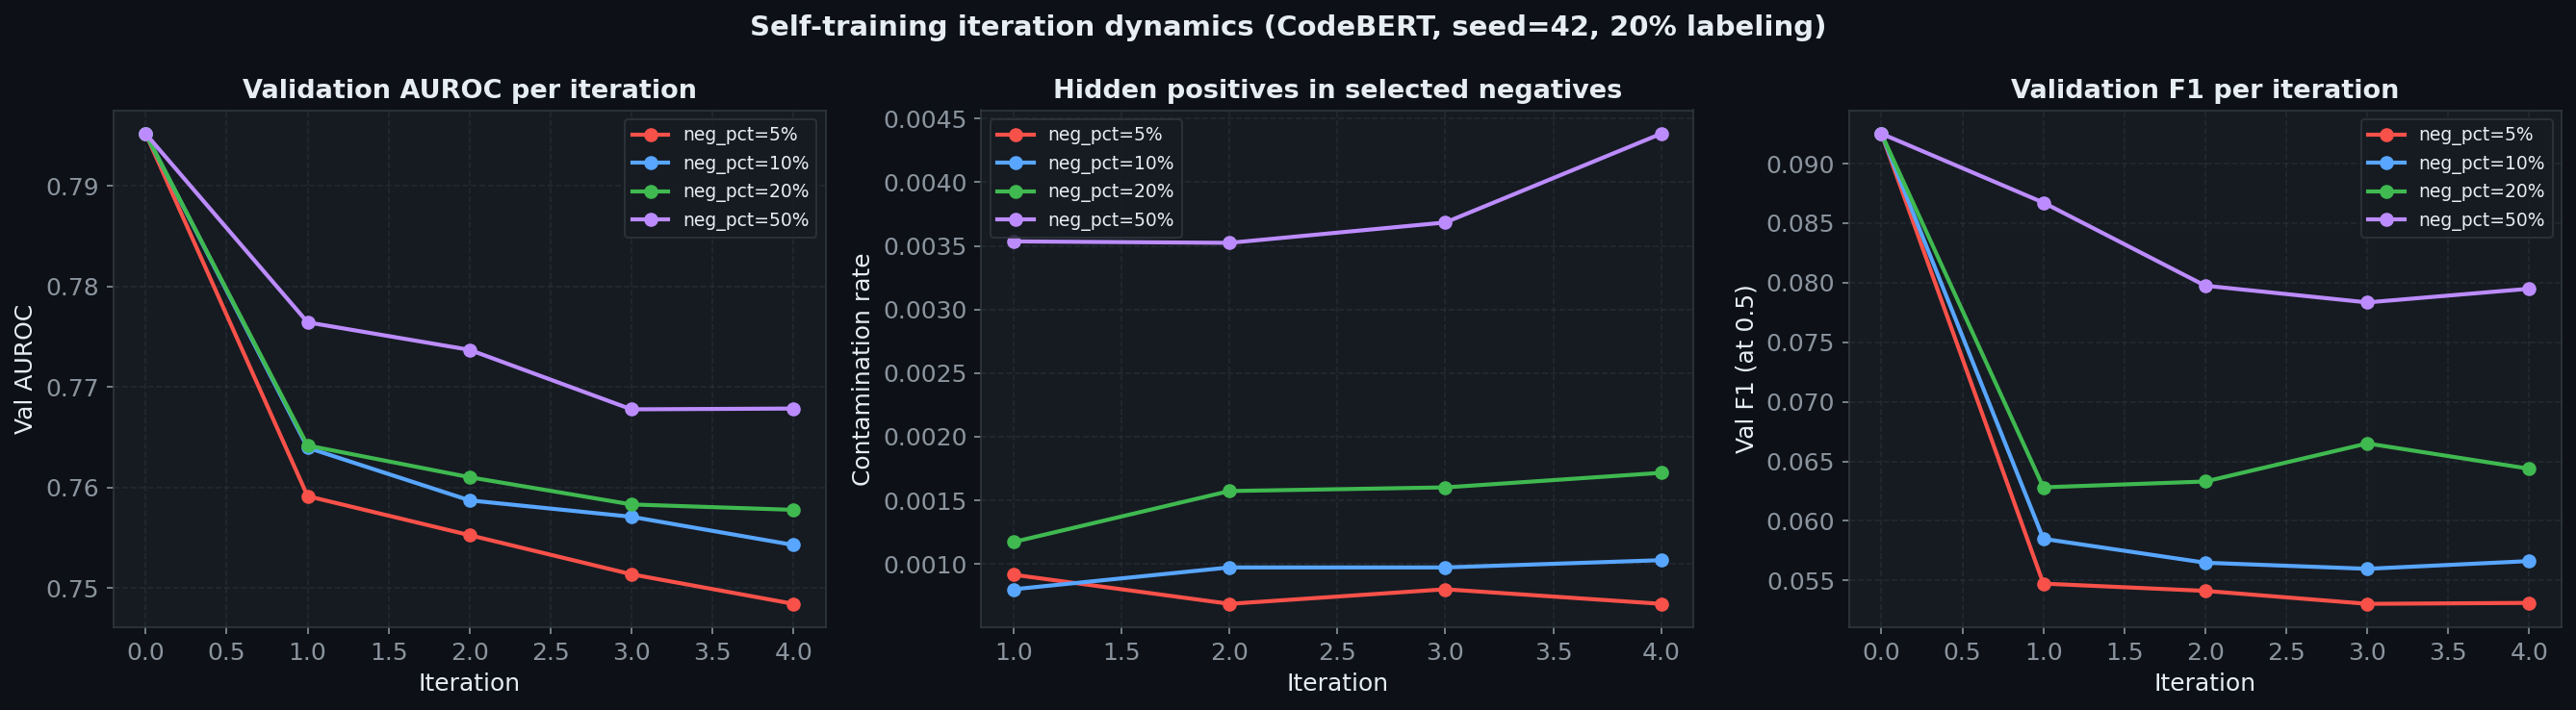

Iteration 0 (naive PU baseline) is always the best.
Subsequent iterations degrade performance regardless of selection rate.


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pct_colors = {0.05: "#f85149", 0.10: "#58a6ff", 0.20: "#3fb950", 0.50: "#bc8cff"}

for pct, hist in iteration_data.items():
    iters = range(len(hist["iter_val_auroc"]))
    color = pct_colors[pct]
    label = f"neg_pct={pct:.0%}"
    
    # Val AUROC per iteration
    axes[0].plot(iters, hist["iter_val_auroc"], "o-", color=color, label=label, linewidth=2, markersize=6)
    
    # Contamination rate per iteration (skip iteration 0 which uses all U)
    if len(hist["iter_contamination_rate"]) > 1:
        axes[1].plot(range(1, len(hist["iter_contamination_rate"])),
                     hist["iter_contamination_rate"][1:],
                     "o-", color=color, label=label, linewidth=2, markersize=6)
    
    # Val F1 per iteration
    axes[2].plot(iters, hist["iter_val_f1"], "o-", color=color, label=label, linewidth=2, markersize=6)

axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Val AUROC")
axes[0].set_title("Validation AUROC per iteration", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Contamination rate")
axes[1].set_title("Hidden positives in selected negatives", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("Val F1 (at 0.5)")
axes[2].set_title("Validation F1 per iteration", fontsize=13, fontweight="bold")

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--")

fig.suptitle("Self-training iteration dynamics (CodeBERT, seed=42, 20% labeling)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb05_self_training_iterations.png", dpi=300, bbox_inches="tight")
plt.show()

print("Iteration 0 (naive PU baseline) is always the best.")
print("Subsequent iterations degrade performance regardless of selection rate.")

In [33]:
# Save CSVs
out_var = ROOT / "experiments" / "logs_reproduce" / "exp4_variance.csv"
out_abl = ROOT / "experiments" / "logs_reproduce" / "exp5_ablation.csv"
df_var.to_csv(out_var, index=False)
df_abl.to_csv(out_abl, index=False)
print(f"Saved {len(df_var)} variance rows to {out_var}")
print(f"Saved {len(df_abl)} ablation rows to {out_abl}")

Saved 18 variance rows to /Users/dbenson/mygit/stat3106/project/experiments/logs_reproduce/exp4_variance.csv
Saved 12 ablation rows to /Users/dbenson/mygit/stat3106/project/experiments/logs_reproduce/exp5_ablation.csv


## 06 CWE analysis

In [34]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, roc_auc_score

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from training import (
    train_supervised, train_naive_pu, train_nnpu, train_self_training,
    find_best_threshold, load_split_embeddings,
)

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3", "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "grid.color": "#30363d", "grid.alpha": 0.5,
    "legend.facecolor": "#161b22", "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3", "font.size": 12, "figure.dpi": 150,
})

EMB_DIR = str(ROOT / "data" / "processed" / "embeddings")
SEEDS = [42, 123, 456, 789, 999]
PRIOR = 0.0277
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# CWE pooling taxonomy
CWE_CATEGORIES = {
    "Memory safety": ["CWE-119", "CWE-125", "CWE-787", "CWE-415", "CWE-416", "CWE-190",
                       "CWE-120", "CWE-122", "CWE-401", "CWE-772", "CWE-824", "CWE-823",
                       "CWE-763", "CWE-908"],
    "Logic / semantic": ["CWE-20", "CWE-476", "CWE-703", "CWE-617", "CWE-754", "CWE-252",
                          "CWE-835", "CWE-834"],
    "Concurrency": ["CWE-362"],
}

In [35]:
import subprocess

# Ensure PU splits exist for seeds 789, 999
for seed in [789, 999]:
    split_dir = ROOT / "data" / "processed" / f"frac0.20_seed{seed}"
    if not split_dir.exists():
        subprocess.run([sys.executable, str(ROOT / "data" / "prepare_pu_splits.py"),
                        "--labeled-frac", "0.20", "--seed", str(seed)],
                       capture_output=True, cwd=str(ROOT))
        print(f"  Created split for seed {seed}")

# Load test data
val = load_split_embeddings(EMB_DIR, "valid")
test = load_split_embeddings(EMB_DIR, "test")
X_val = torch.tensor(val["embeddings"], dtype=torch.float32).to(device)
X_test = torch.tensor(test["embeddings"], dtype=torch.float32).to(device)
vuln_mask = test["labels"] == 1
vuln_cwes = test["cwe_types"][vuln_mask]

# Train all methods at 20% labeling, 5 seeds
methods = {
    "supervised": lambda s: train_supervised(EMB_DIR, seed=s, device=device),
    "naive_pu": lambda s: train_naive_pu(EMB_DIR, 0.20, s, s, device=device),
    "nnpu": lambda s: train_nnpu(EMB_DIR, 0.20, s, s, PRIOR, device=device),
    "self_training": lambda s: train_self_training(EMB_DIR, 0.20, s, s, device=device),
}

cwe_rows = []
for seed in SEEDS:
    for method_name, train_fn in methods.items():
        model, _ = train_fn(seed)
        thr, _ = find_best_threshold(model, X_val, val["labels"])
        with torch.no_grad():
            probs = model.predict_proba(X_test).cpu().numpy()
        preds = (probs >= thr).astype(int)
        vuln_preds = preds[vuln_mask]
        
        for cat_name, cat_cwes in CWE_CATEGORIES.items():
            cat_mask = np.isin(vuln_cwes, cat_cwes)
            n = int(cat_mask.sum())
            if n > 0:
                recall = float(vuln_preds[cat_mask].mean())
                cwe_rows.append({
                    "method": method_name, "seed": seed, "category": cat_name,
                    "n_test": n, "recall": round(recall, 4),
                })
    print(f"  Seed {seed}: done (4 methods)")

df_cwe = pd.DataFrame(cwe_rows)
print(f"\n{len(df_cwe)} CWE rows collected")

  Seed 42: done (4 methods)
  Seed 123: done (4 methods)
  Seed 456: done (4 methods)
  Seed 789: done (4 methods)
  Seed 999: done (4 methods)

60 CWE rows collected


=== Pooled Category Recall (mean +/- std, 5 seeds) ===

Memory safety:
  supervised       0.368 +/- 0.036  (n_test=271)
  naive_pu         0.334 +/- 0.085  (n_test=271)
  nnpu             0.321 +/- 0.039  (n_test=271)
  self_training    0.297 +/- 0.084  (n_test=271)

Logic / semantic:
  supervised       0.250 +/- 0.024  (n_test=145)
  naive_pu         0.219 +/- 0.085  (n_test=145)
  nnpu             0.240 +/- 0.039  (n_test=145)
  self_training    0.177 +/- 0.068  (n_test=145)

Concurrency:
  supervised       0.100 +/- 0.000  (n_test=10)
  naive_pu         0.140 +/- 0.055  (n_test=10)
  nnpu             0.120 +/- 0.045  (n_test=10)
  self_training    0.160 +/- 0.089  (n_test=10)



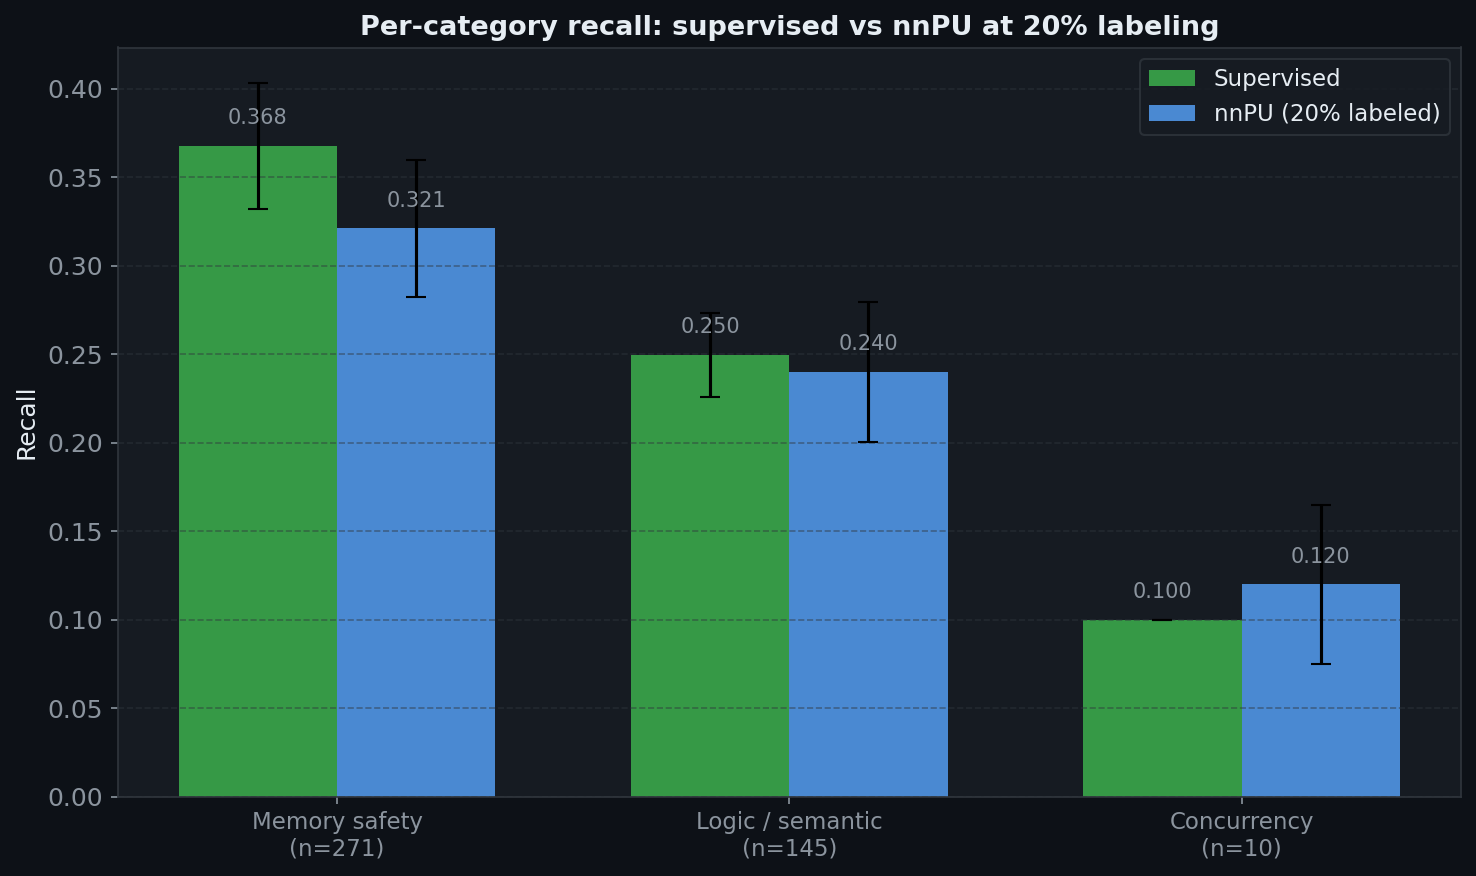

In [36]:
# Summary table
print("=== Pooled Category Recall (mean +/- std, 5 seeds) ===\n")
for cat in ["Memory safety", "Logic / semantic", "Concurrency"]:
    print(f"{cat}:")
    for method in ["supervised", "naive_pu", "nnpu", "self_training"]:
        vals = df_cwe[(df_cwe["category"] == cat) & (df_cwe["method"] == method)]["recall"]
        if len(vals) > 0:
            n = df_cwe[(df_cwe["category"] == cat) & (df_cwe["method"] == method)]["n_test"].iloc[0]
            print(f"  {method:15s}  {vals.mean():.3f} +/- {vals.std():.3f}  (n_test={n})")
    print()

# Bar chart: supervised vs nnPU
fig, ax = plt.subplots(figsize=(10, 6))
categories = ["Memory safety", "Logic / semantic", "Concurrency"]
x = np.arange(len(categories))
width = 0.35

sup_means = [df_cwe[(df_cwe["category"] == c) & (df_cwe["method"] == "supervised")]["recall"].mean() for c in categories]
sup_stds = [df_cwe[(df_cwe["category"] == c) & (df_cwe["method"] == "supervised")]["recall"].std() for c in categories]
nnpu_means = [df_cwe[(df_cwe["category"] == c) & (df_cwe["method"] == "nnpu")]["recall"].mean() for c in categories]
nnpu_stds = [df_cwe[(df_cwe["category"] == c) & (df_cwe["method"] == "nnpu")]["recall"].std() for c in categories]

bars1 = ax.bar(x - width/2, sup_means, width, yerr=sup_stds, label="Supervised",
               color="#3fb950", alpha=0.8, capsize=5)
bars2 = ax.bar(x + width/2, nnpu_means, width, yerr=nnpu_stds, label="nnPU (20% labeled)",
               color="#58a6ff", alpha=0.8, capsize=5)

ax.set_ylabel("Recall")
ax.set_title("Per-category recall: supervised vs nnPU at 20% labeling", fontsize=13, fontweight="bold")
ax.set_xticks(x)
n_tests = [df_cwe[(df_cwe["category"] == c)]["n_test"].iloc[0] for c in categories]
ax.set_xticklabels([f"{c}\n(n={n})" for c, n in zip(categories, n_tests)], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--")

# Value labels
for bars, means in [(bars1, sup_means), (bars2, nnpu_means)]:
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, color="#8b949e")

plt.tight_layout()
plt.savefig(ROOT / "figures" / "reproduce" / "nb06_per_cwe_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# Save CSV
out_path = ROOT / "experiments" / "logs_reproduce" / "exp6_cwe.csv"
df_cwe.to_csv(out_path, index=False)
print(f"Saved {len(df_cwe)} rows to {out_path}")


Saved 60 rows to /Users/dbenson/mygit/stat3106/project/experiments/logs_reproduce/exp6_cwe.csv


## Manifest

In [38]:
from pathlib import Path

ROOT = Path("..").resolve()
fig_dir = ROOT / "figures" / "reproduce"
log_dir = ROOT / "experiments" / "logs_reproduce"

print("Regenerated figures:")
for p in sorted(fig_dir.glob("*.png")):
    print(f"  {p.name}  {p.stat().st_size // 1024} KB")
print()
print("Regenerated CSVs:")
for p in sorted(log_dir.glob("*.csv")):
    print(f"  {p.name}  {p.stat().st_size} bytes")


Regenerated figures:
  nb01_cwe_distribution.png  261 KB
  nb01_embedding_norms.png  140 KB
  nb01_umap_comparison.png  2158 KB
  nb02_calibration_histograms.png  136 KB
  nb02_cb_vs_vb_auroc.png  118 KB
  nb02_training_curves_cb.png  417 KB
  nb03_extreme_fractions.png  402 KB
  nb03_labeling_curves.png  1105 KB
  nb04_prior_sensitivity.png  366 KB
  nb05_self_training_iterations.png  504 KB
  nb05_variance_decomp.png  415 KB
  nb06_per_cwe_comparison.png  151 KB

Regenerated CSVs:
  exp1_baseline.csv  1396 bytes
  exp2_labeling.csv  3443 bytes
  exp2_labeling_vulberta.csv  3443 bytes
  exp3_prior.csv  795 bytes
  exp4_variance.csv  462 bytes
  exp5_ablation.csv  320 bytes
  exp6_cwe.csv  2286 bytes
